In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


****PHASE 1: PROBLEM STATEMENT + DATA OVERVIEW****

About Dataset
Clustering the Countries by using Unsupervised Learning for HELP International
Objective:
To categorise the countries using socio-economic and health factors that determine the overall development of the country.

About organization:
HELP International is an international humanitarian NGO that is committed to fighting poverty and providing the people of backward countries with basic amenities and relief during the time of disasters and natural calamities.

Problem Statement:
HELP International have been able to raise around $ 10 million. Now the CEO of the NGO needs to decide how to use this money strategically and effectively. So, CEO has to make decision to choose the countries that are in the direst need of aid. Hence, your Job as a Data scientist is to categorise the countries using some socio-economic and health factors that determine the overall development of the country. Then you need to suggest the countries which the CEO needs to focus on the most.

1. Problem Statement + Data Overview
2. EDA + Advanced EDA
3. Data Cleaning & Preprocessing
4. Feature Engineering
5. Feature Scaling
6. PCA
7. KMeans Clustering
8. DBSCAN Clustering
9. Cluster Evaluation
10. Cluster Interpretation
11. Label Creation
12. Train-Test Split + Dataset Preparation
13. Classification Models + Ensembling
14. Hyperparameter Tuning
15. Model Evaluation
16. Final Pipeline + CSV Export

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors

import warnings
warnings.filterwarnings("ignore")

In [3]:
COUNTRY_DATA_PATH = "/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv"
DATA_DICT_PATH = "/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv"

df = pd.read_csv(COUNTRY_DATA_PATH)
data_dict = pd.read_csv(DATA_DICT_PATH)

In [4]:
print(data_dict.columns)
print(data_dict.index)

Index(['Column Name', 'Description'], dtype='object')
RangeIndex(start=0, stop=10, step=1)


In [5]:
for i in data_dict.index:
    print(f"{data_dict.loc[i, "Column Name"]}: {data_dict.loc[i, "Description"]}")

country: Name of the country
child_mort: Death of children under 5 years of age per 1000 live births
exports: Exports of goods and services per capita. Given as %age of the GDP per capita
health: Total health spending per capita. Given as %age of GDP per capita
imports: Imports of goods and services per capita. Given as %age of the GDP per capita
Income: Net income per person
Inflation: The measurement of the annual growth rate of the Total GDP
life_expec: The average number of years a new born child would live if the current mortality patterns are to remain the same
total_fer: The number of children that would be born to each woman if the current age-fertility rates remain the same.
gdpp: The GDP per capita. Calculated as the Total GDP divided by the total population.


In [6]:
print(df.columns)
print(df.index)
print()
df.head()

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')
RangeIndex(start=0, stop=167, step=1)



,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [7]:
df.shape

(167, 10)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,38.270060,40.328931,2.6000,8.250,19.30,62.10,208.00
exports,167.0,41.108976,27.412010,0.1090,23.800,35.00,51.35,200.00
health,167.0,6.815689,2.746837,1.8100,4.920,6.32,8.60,17.90
imports,167.0,46.890215,24.209589,0.0659,30.200,43.30,58.75,174.00
income,167.0,17144.688623,19278.067698,609.0000,3355.000,9960.00,22800.00,125000.00
inflation,167.0,7.781832,10.570704,-4.2100,1.810,5.39,10.75,104.00
life_expec,167.0,70.555689,8.893172,32.1000,65.300,73.10,76.80,82.80
total_fer,167.0,2.947964,1.513848,1.1500,1.795,2.41,3.88,7.49
gdpp,167.0,12964.155689,18328.704809,231.0000,1330.000,4660.00,14050.00,105000.00


In [10]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["country"].duplicated().sum()

np.int64(0)

In [13]:
df.nunique()

country       167
child_mort    139
exports       147
health        147
imports       151
income        156
inflation     156
life_expec    127
total_fer     138
gdpp          157
dtype: int64

In [14]:
df.dtypes

country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

In [15]:
# Separate numerical columns
num_cols = df.select_dtypes(include=np.number).columns.tolist()

num_cols

['child_mort',
 'exports',
 'health',
 'imports',
 'income',
 'inflation',
 'life_expec',
 'total_fer',
 'gdpp']

In [16]:
# Mean, Median, Std Comparison
stats_df = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Std': df[num_cols].std(),
    'Min': df[num_cols].min(),
    'Max': df[num_cols].max(),
    'Skewness': df[num_cols].skew(),
    'Kurtosis': df[num_cols].kurtosis()
})

stats_df

,Mean,Median,Std,Min,Max,Skewness,Kurtosis
child_mort,38.270060,19.30,40.328931,2.6000,208.00,1.450774,1.766882
exports,41.108976,35.00,27.412010,0.1090,200.00,2.445824,10.138666
health,6.815689,6.32,2.746837,1.8100,17.90,0.705746,0.694196
imports,46.890215,43.30,24.209589,0.0659,174.00,1.905276,6.755854
income,17144.688623,9960.00,19278.067698,609.0000,125000.00,2.231480,7.028657
inflation,7.781832,5.39,10.570704,-4.2100,104.00,5.154049,41.742502
life_expec,70.555689,73.10,8.893172,32.1000,82.80,-0.970996,1.151591
total_fer,2.947964,2.41,1.513848,1.1500,7.49,0.967092,-0.186779
gdpp,12964.155689,4660.00,18328.704809,231.0000,105000.00,2.218051,5.527891


****PHASE 2: EXPLORATORY DATA ANALYSIS****

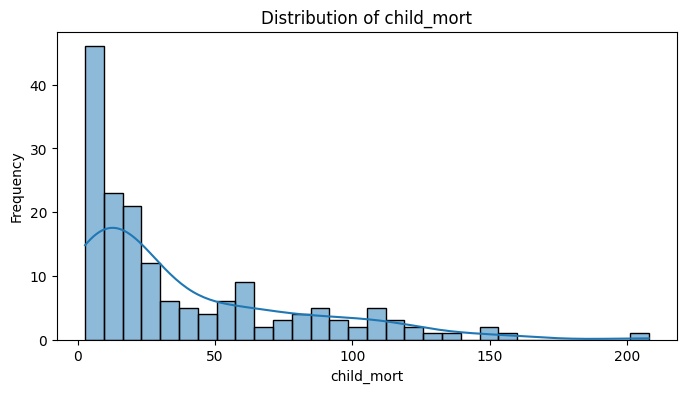

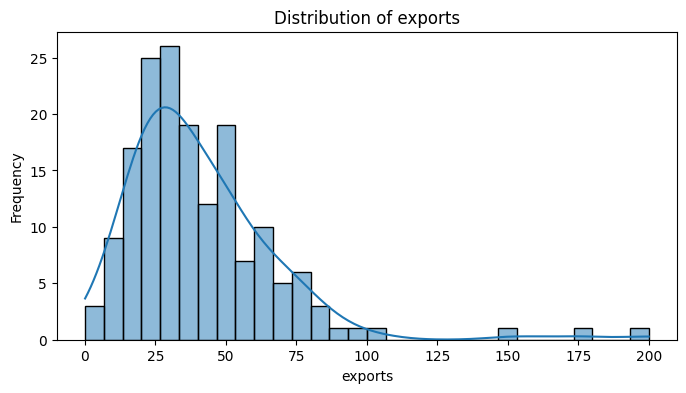

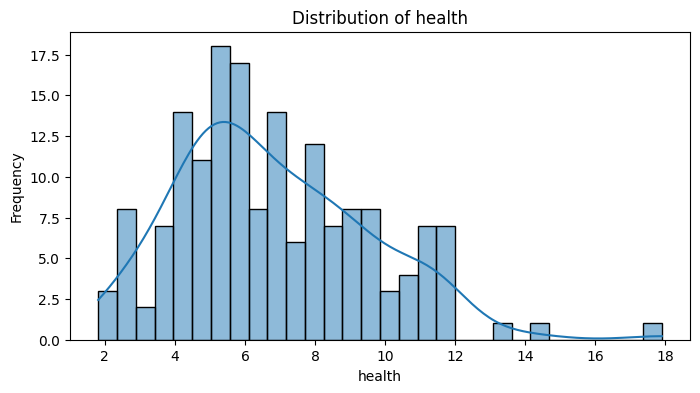

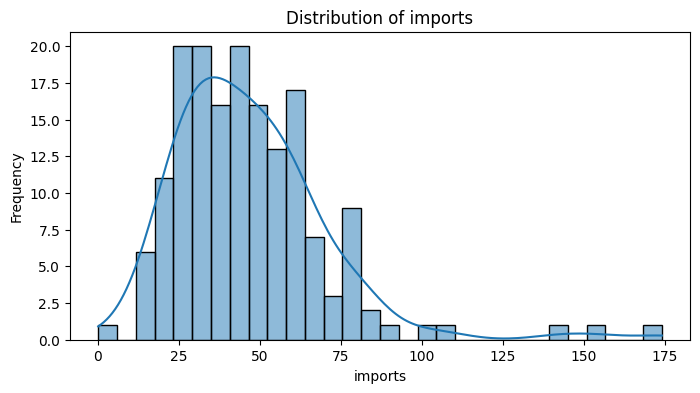

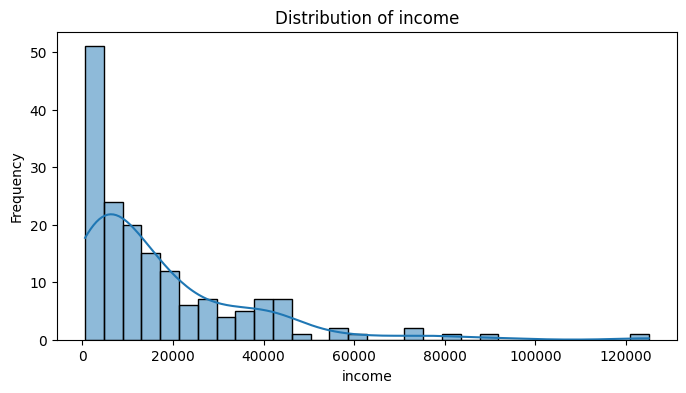

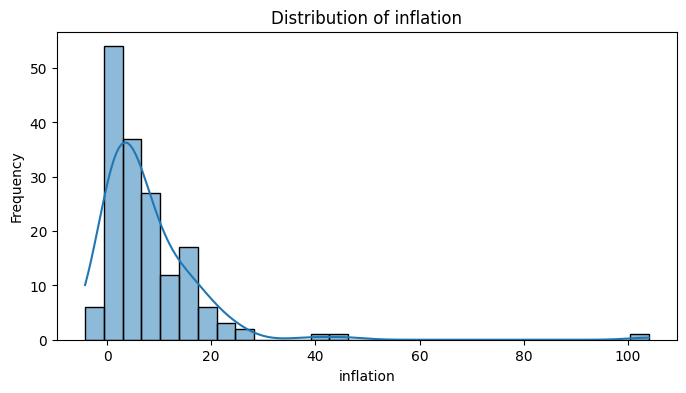

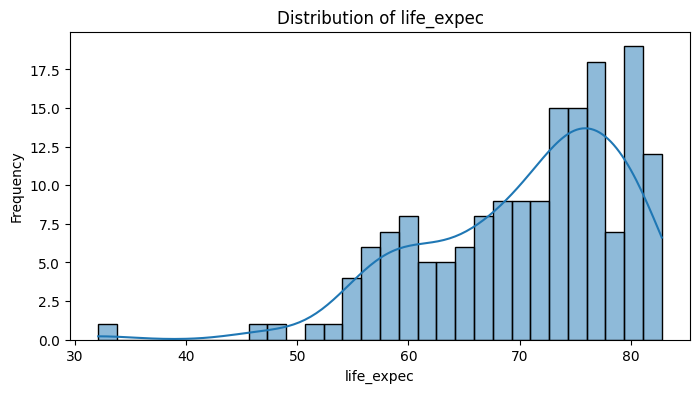

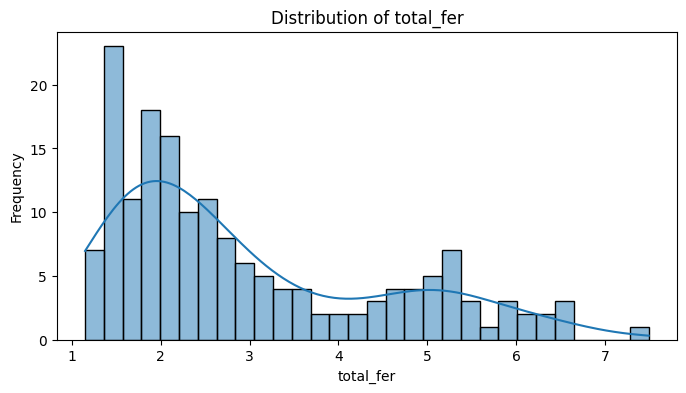

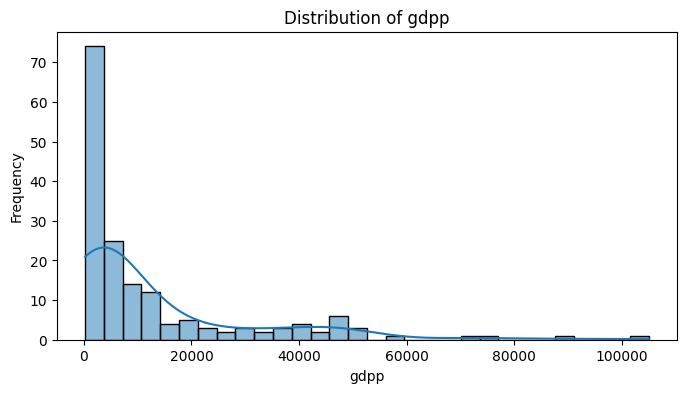

In [17]:
# Histograms with KDE
for col in num_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.histplot(df[col], kde=True, bins=30)
    
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    plt.show()

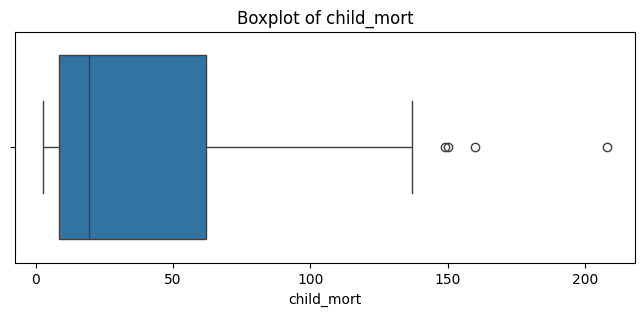

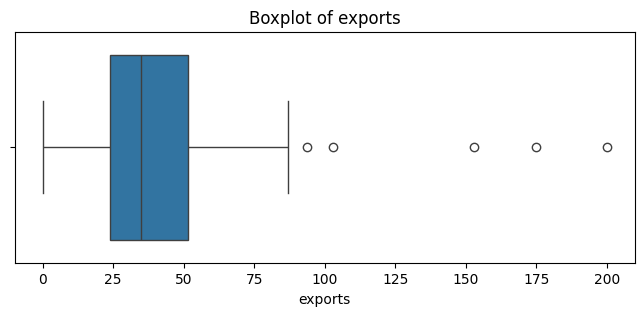

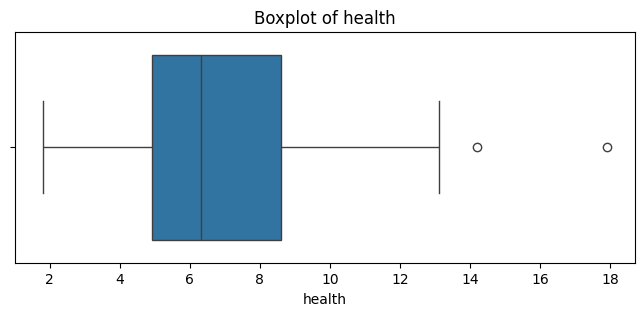

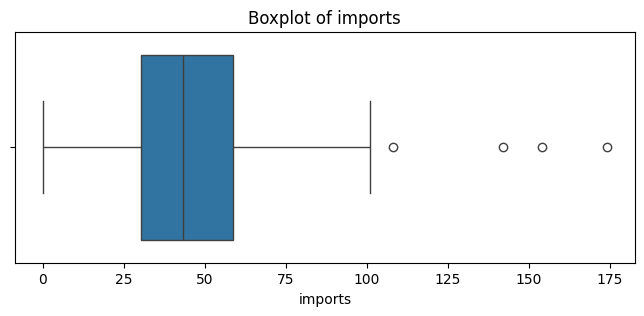

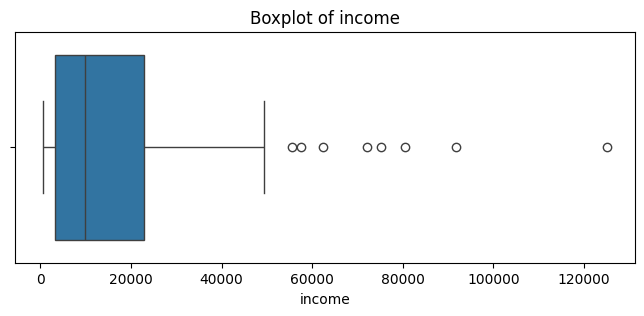

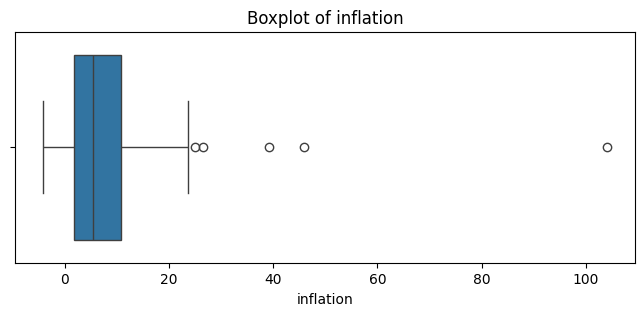

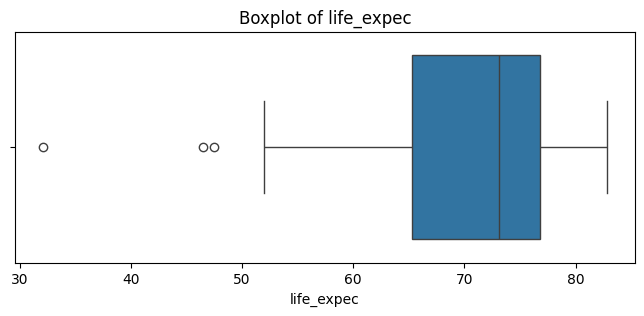

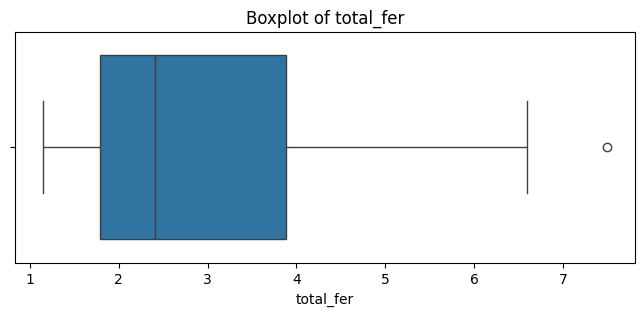

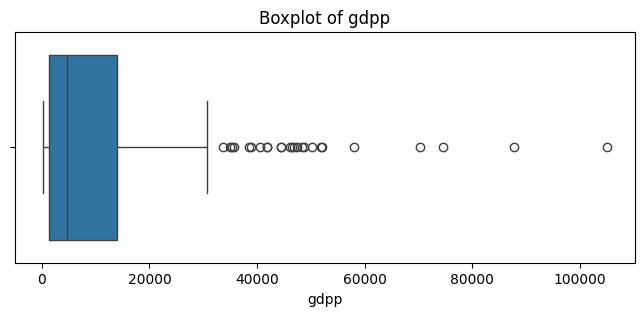

In [18]:
# Boxplots
for col in num_cols:
    
    plt.figure(figsize=(8,3))
    
    sns.boxplot(x=df[col])
    
    plt.title(f'Boxplot of {col}')
    
    plt.show()

In [19]:
# Skewness values
skewness_df = pd.DataFrame({
    'Feature': num_cols,
    'Skewness': [df[col].skew() for col in num_cols]
})

skewness_df.sort_values(by='Skewness', ascending=False)

,Feature,Skewness
5,inflation,5.154049
1,exports,2.445824
4,income,2.231480
8,gdpp,2.218051
3,imports,1.905276
0,child_mort,1.450774
7,total_fer,0.967092
2,health,0.705746
6,life_expec,-0.970996


In [20]:
# Kurtosis values
kurtosis_df = pd.DataFrame({
    'Feature': num_cols,
    'Kurtosis': [df[col].kurtosis() for col in num_cols]
})

kurtosis_df.sort_values(by='Kurtosis', ascending=False)

,Feature,Kurtosis
5,inflation,41.742502
1,exports,10.138666
4,income,7.028657
3,imports,6.755854
8,gdpp,5.527891
0,child_mort,1.766882
6,life_expec,1.151591
2,health,0.694196
7,total_fer,-0.186779


In [21]:
# Pearson Correlation Matrix
corr_matrix = df[num_cols].corr(method='pearson')

corr_matrix

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
child_mort,1.000000,-0.318093,-0.200402,-0.127211,-0.524315,0.288276,-0.886676,0.848478,-0.483032
exports,-0.318093,1.000000,-0.114408,0.737381,0.516784,-0.107294,0.316313,-0.320011,0.418725
health,-0.200402,-0.114408,1.000000,0.095717,0.129579,-0.255376,0.210692,-0.196674,0.345966
imports,-0.127211,0.737381,0.095717,1.000000,0.122406,-0.246994,0.054391,-0.159048,0.115498
income,-0.524315,0.516784,0.129579,0.122406,1.000000,-0.147756,0.611962,-0.501840,0.895571
inflation,0.288276,-0.107294,-0.255376,-0.246994,-0.147756,1.000000,-0.239705,0.316921,-0.221631
life_expec,-0.886676,0.316313,0.210692,0.054391,0.611962,-0.239705,1.000000,-0.760875,0.600089
total_fer,0.848478,-0.320011,-0.196674,-0.159048,-0.501840,0.316921,-0.760875,1.000000,-0.454910
gdpp,-0.483032,0.418725,0.345966,0.115498,0.895571,-0.221631,0.600089,-0.454910,1.000000


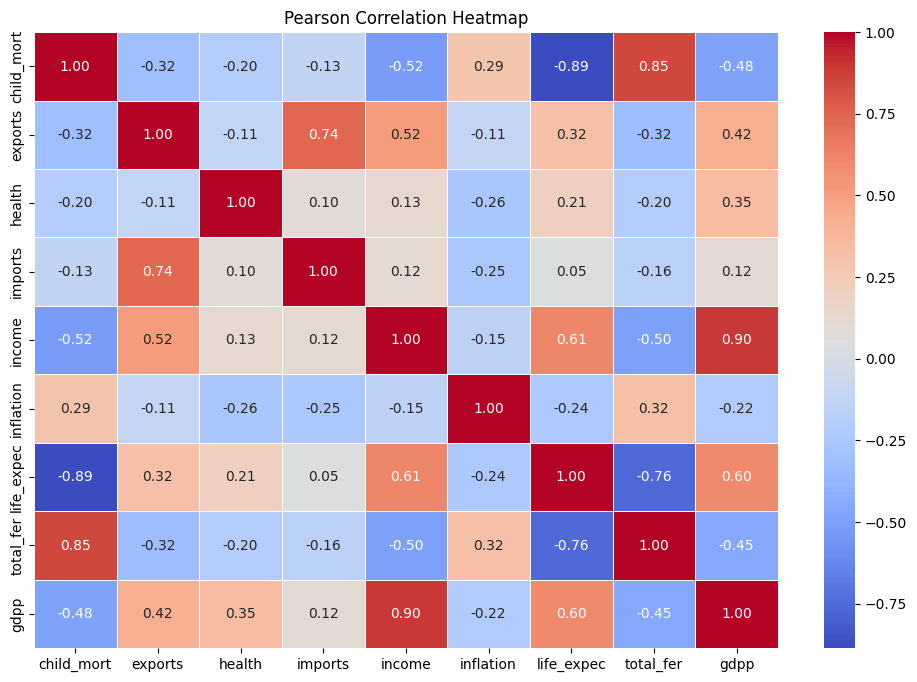

In [22]:
# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Pearson Correlation Heatmap")

plt.show()

In [23]:
# Spearman Correlation
spearman_corr = df[num_cols].corr(method='spearman')

spearman_corr

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
child_mort,1.000000,-0.399625,-0.369941,-0.123087,-0.866788,0.485936,-0.905604,0.869709,-0.875750
exports,-0.399625,1.000000,-0.092690,0.573174,0.511420,-0.119464,0.313471,-0.349557,0.472109
health,-0.369941,-0.092690,1.000000,0.123825,0.196980,-0.388105,0.317849,-0.311403,0.286879
imports,-0.123087,0.573174,0.123825,1.000000,-0.015251,-0.292669,-0.007793,-0.137392,-0.000203
income,-0.866788,0.511420,0.196980,-0.015251,1.000000,-0.319656,0.842012,-0.740134,0.978183
inflation,0.485936,-0.119464,-0.388105,-0.292669,-0.319656,1.000000,-0.430346,0.442204,-0.395986
life_expec,-0.905604,0.313471,0.317849,-0.007793,0.842012,-0.430346,1.000000,-0.766692,0.851278
total_fer,0.869709,-0.349557,-0.311403,-0.137392,-0.740134,0.442204,-0.766692,1.000000,-0.731430
gdpp,-0.875750,0.472109,0.286879,-0.000203,0.978183,-0.395986,0.851278,-0.731430,1.000000


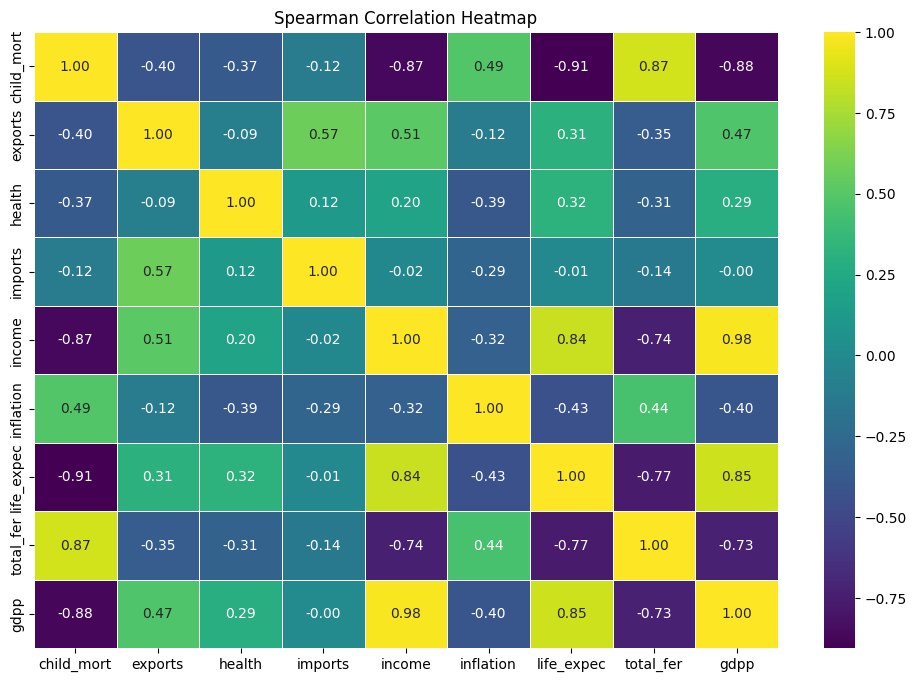

In [24]:
# Spearman Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    spearman_corr,
    annot=True,
    cmap='viridis',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Spearman Correlation Heatmap")

plt.show()

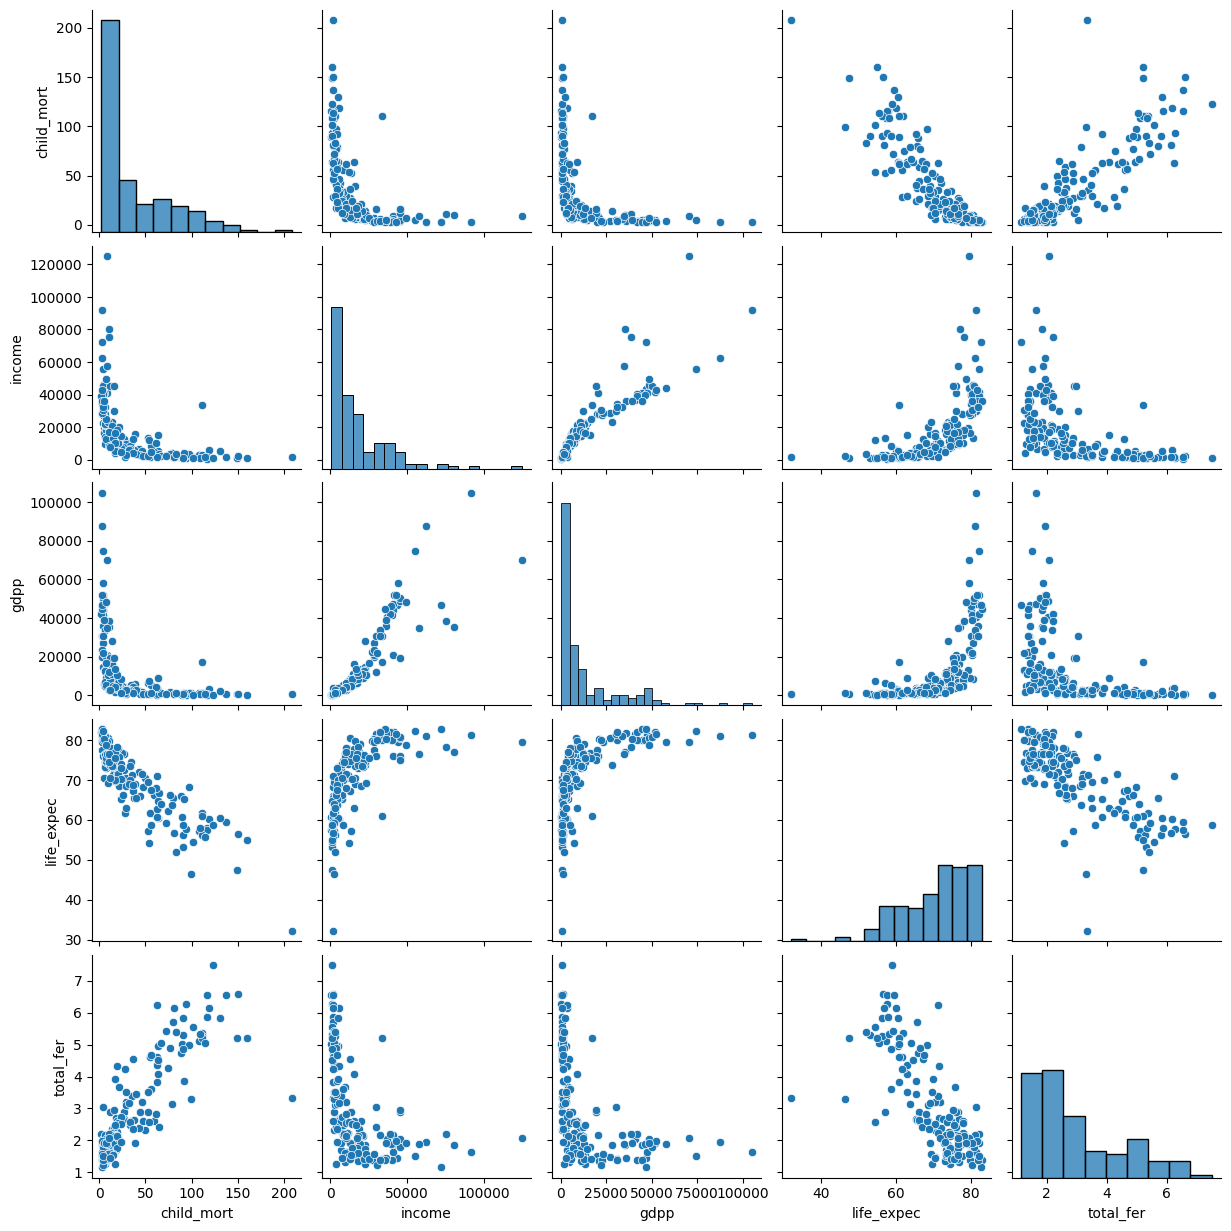

In [25]:
# Selected important features
selected_features = [
    'child_mort',
    'income',
    'gdpp',
    'life_expec',
    'total_fer'
]

sns.pairplot(df[selected_features])

plt.show()

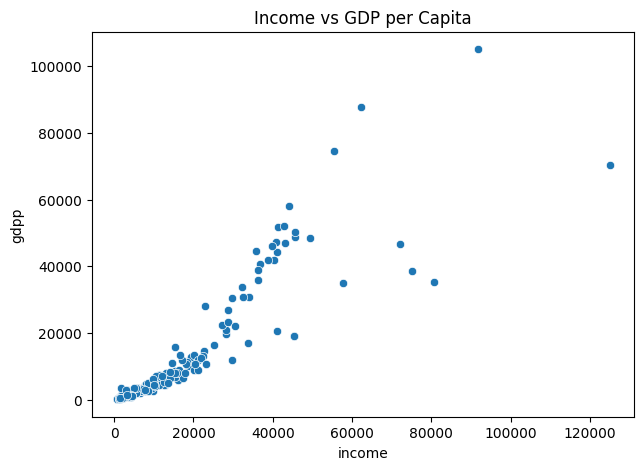

In [26]:
# Income vs GDP
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='income',
    y='gdpp'
)

plt.title("Income vs GDP per Capita")

plt.show()

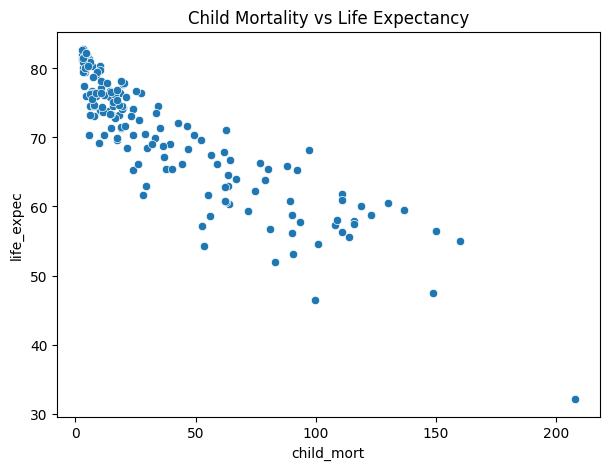

In [27]:
# Child Mortality vs Life Expectancy
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='child_mort',
    y='life_expec'
)

plt.title("Child Mortality vs Life Expectancy")

plt.show()

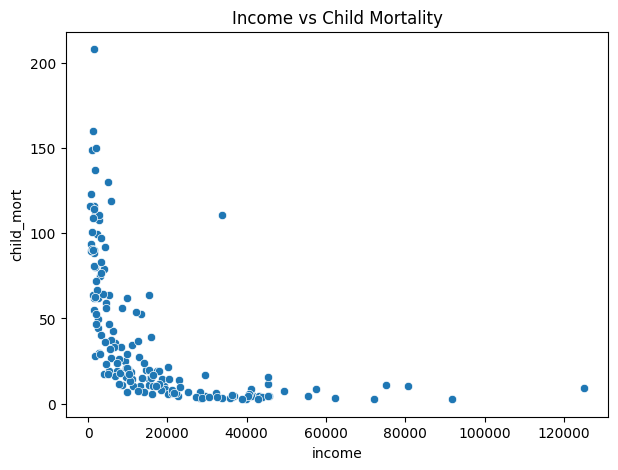

In [28]:
# Income vs Child Mortality
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x='income',
    y='child_mort'
)

plt.title("Income vs Child Mortality")

plt.show()

In [29]:
# IQR Outlier Counts

outlier_summary = {}

for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)
    
    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]
    
    outlier_summary[col] = len(outliers)

pd.DataFrame.from_dict(
    outlier_summary,
    orient='index',
    columns=['Outlier Count']
).sort_values(by='Outlier Count', ascending=False)

,Outlier Count
gdpp,25
income,8
inflation,5
exports,5
child_mort,4
imports,4
life_expec,3
health,2
total_fer,1


In [30]:
# Top GDP countries
df[['country', 'gdpp']].sort_values(
    by='gdpp',
    ascending=False
).head(10)

,country,gdpp
91,Luxembourg,105000
114,Norway,87800
145,Switzerland,74600
123,Qatar,70300
44,Denmark,58000
144,Sweden,52100
7,Australia,51900
110,Netherlands,50300
73,Ireland,48700
159,United States,48400


In [31]:
df[['country', 'child_mort']].sort_values(
    by='child_mort',
    ascending=False
).head(10)

,country,child_mort
66,Haiti,208.0
132,Sierra Leone,160.0
32,Chad,150.0
31,Central African Republic,149.0
97,Mali,137.0
113,Nigeria,130.0
112,Niger,123.0
3,Angola,119.0
25,Burkina Faso,116.0
37,"Congo, Dem. Rep.",116.0


In [32]:
df[['country', 'inflation']].sort_values(
    by='inflation',
    ascending=False
).head(10)

,country,inflation
113,Nigeria,104.0
163,Venezuela,45.9
103,Mongolia,39.2
149,Timor-Leste,26.5
49,Equatorial Guinea,24.9
165,Yemen,23.6
140,Sri Lanka,22.8
3,Angola,22.4
5,Argentina,20.9
37,"Congo, Dem. Rep.",20.8


****PHASE 3: DATA CLEANING AND PREPROCESSING****

In [33]:
df_processed = df.copy()

In [34]:
country_names = df_processed['country']

df_processed.drop(
    columns=['country'],
    inplace=True
)

In [35]:
df_processed.dtypes

child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object

In [36]:
inflation_shift = abs(
    df_processed['inflation'].min()
) + 1

print(inflation_shift)

5.21


In [37]:
df_processed['inflation'] = (
    df_processed['inflation'] + inflation_shift
)

In [38]:
# Apply log1p transformation

for col in df_processed.columns:
    
    df_processed[col] = np.log1p(
        df_processed[col]
    )

df_processed.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,4.513055,2.397895,2.149434,3.826465,7.384610,2.750471,4.046554,1.919859,6.317165
1,2.867899,3.367296,2.021548,3.903991,9.203416,2.370244,4.347694,0.974560,8.316545
2,3.342862,3.673766,1.642873,3.478158,9.465060,3.105035,4.350278,1.358409,8.403128
3,4.787492,4.147885,1.348073,3.781914,8.682877,3.353756,4.112512,1.968510,8.169336
4,2.424803,3.839452,1.950187,4.092677,9.857496,2.034706,4.354141,1.141033,9.409273


In [39]:
original_skewness = df.drop(
    columns=['country']
).skew()

transformed_skewness = df_processed.skew()

skewness_comparison = pd.DataFrame({
    'Original': original_skewness,
    'Transformed': transformed_skewness
})

skewness_comparison

,Original,Transformed
child_mort,1.450774,0.066160
exports,2.445824,-1.088961
health,0.705746,-0.230272
imports,1.905276,-1.822794
income,2.231480,-0.235823
inflation,5.154049,0.452282
life_expec,-0.970996,-1.626466
total_fer,0.967092,0.540171
gdpp,2.218051,0.006548


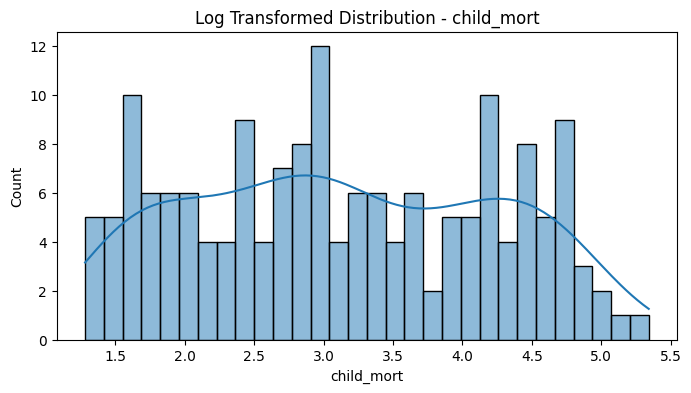

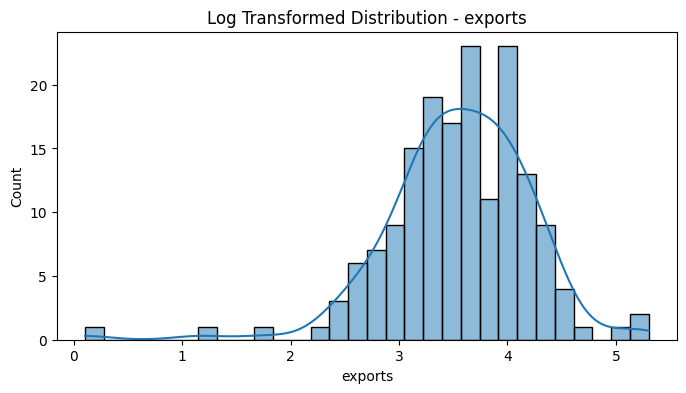

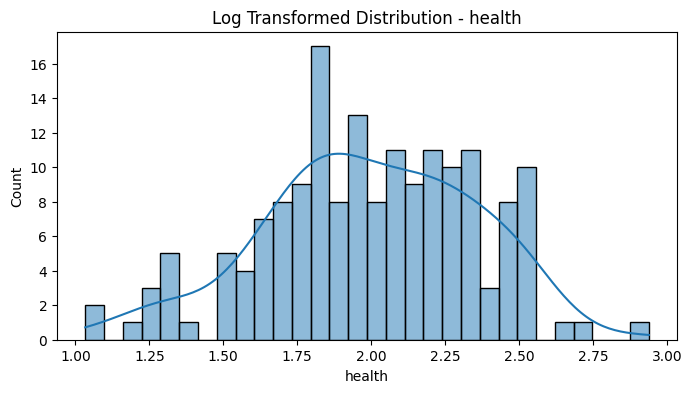

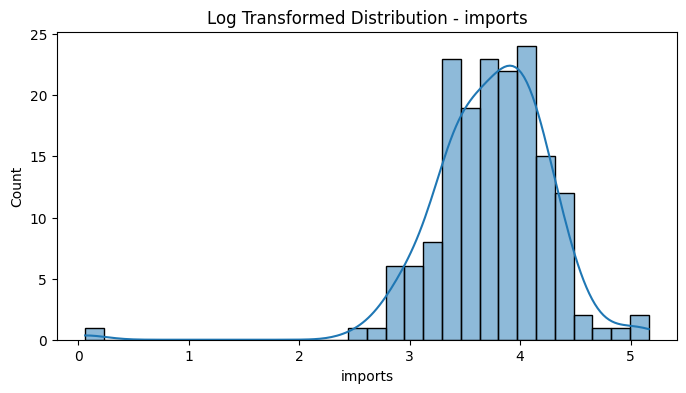

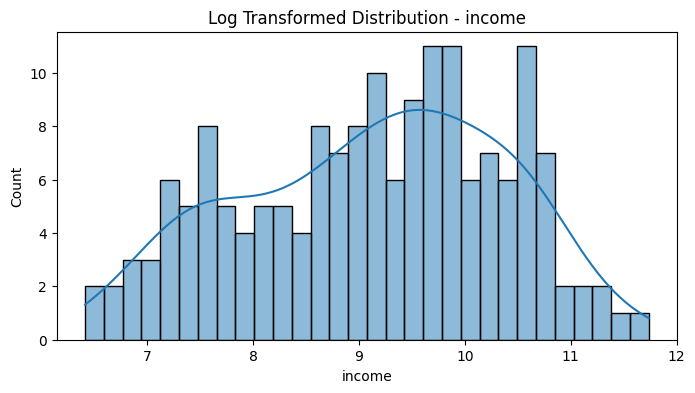

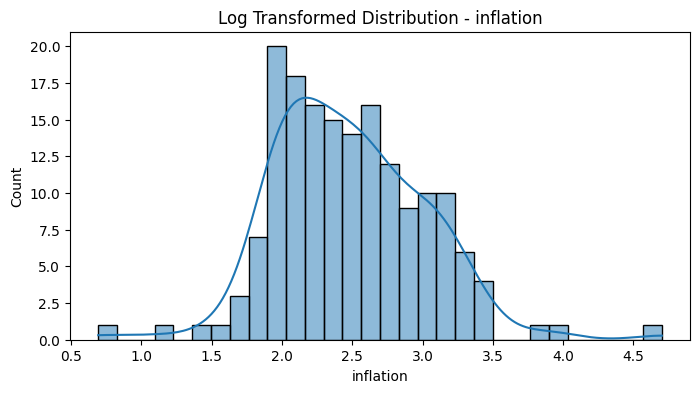

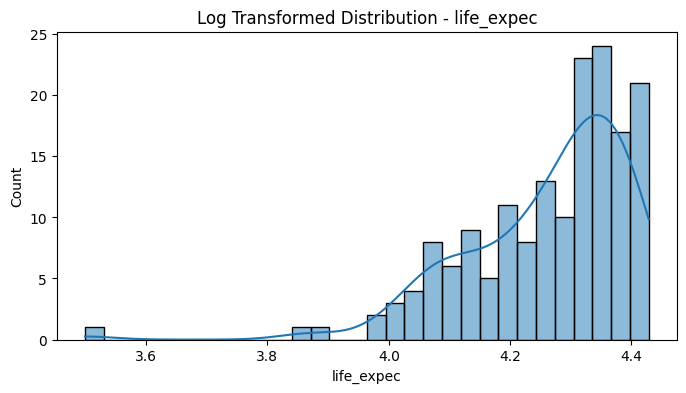

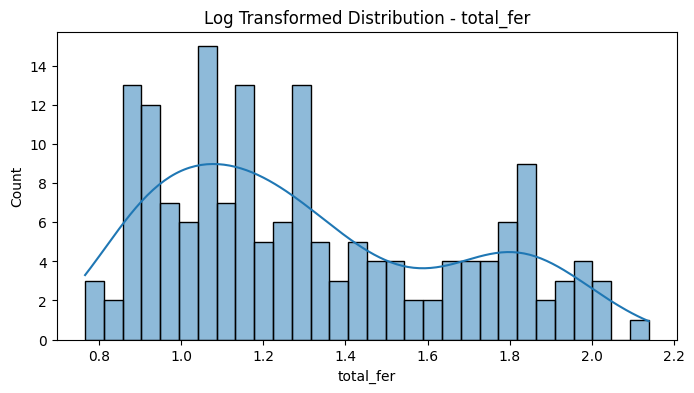

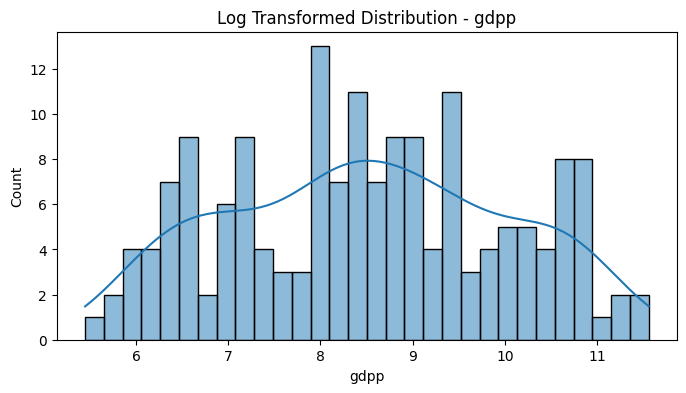

In [40]:
for col in df_processed.columns:
    
    plt.figure(figsize=(8,4))
    
    sns.histplot(
        df_processed[col],
        kde=True,
        bins=30
    )
    
    plt.title(f'Log Transformed Distribution - {col}')
    
    plt.show()

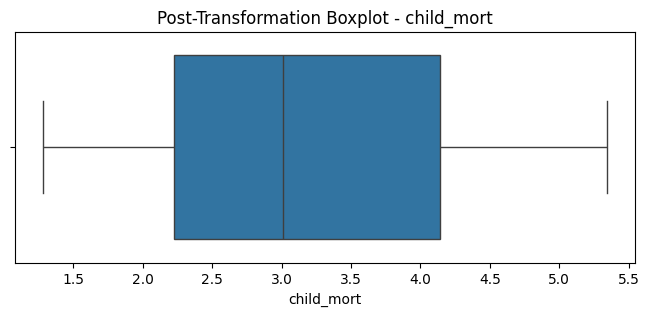

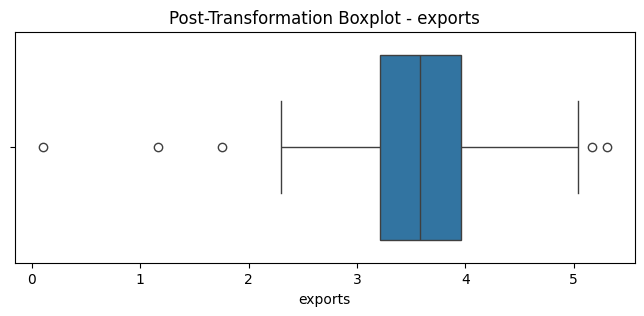

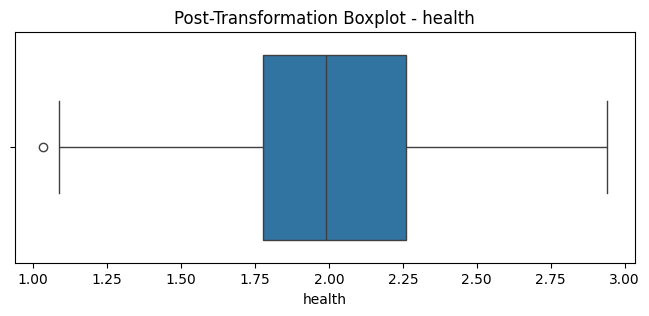

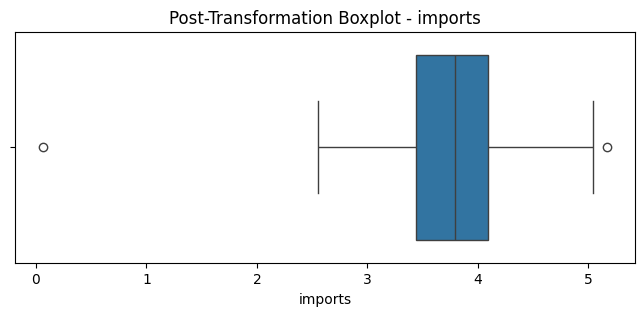

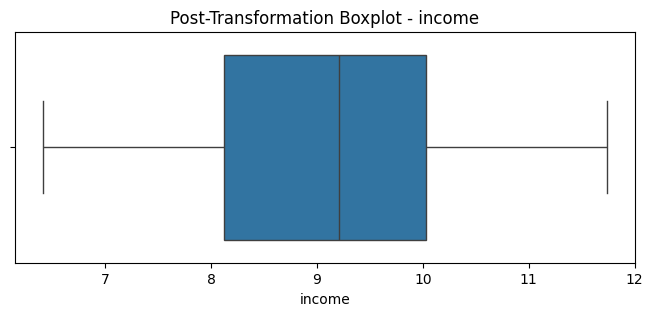

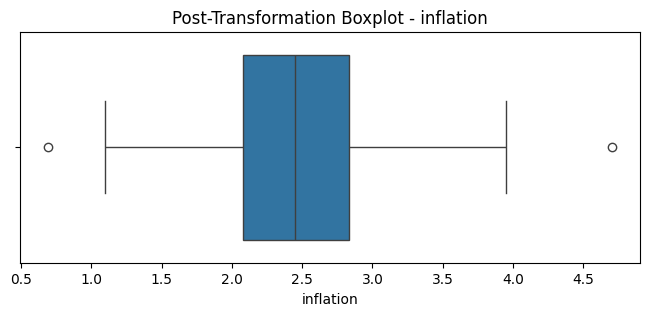

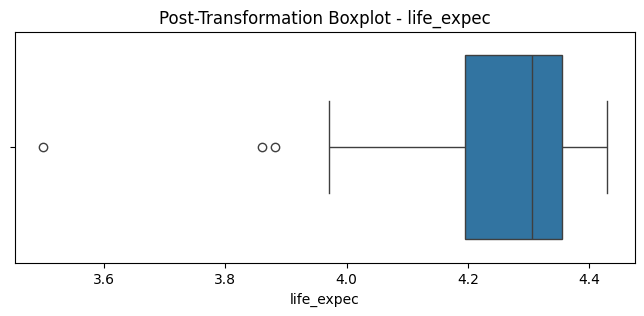

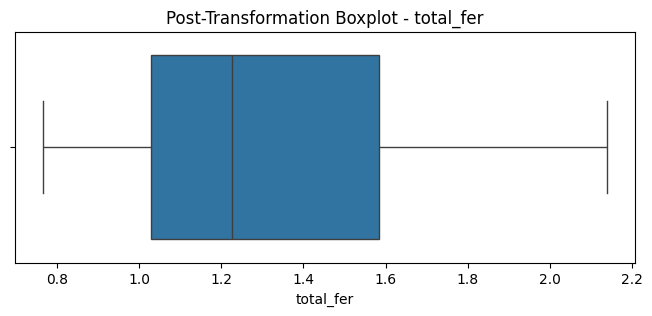

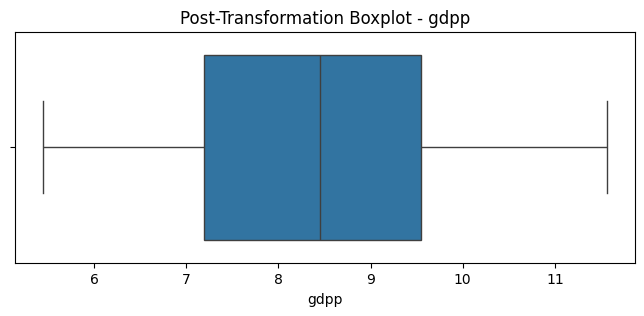

In [41]:
for col in df_processed.columns:
    
    plt.figure(figsize=(8,3))
    
    sns.boxplot(x=df_processed[col])
    
    plt.title(f'Post-Transformation Boxplot - {col}')
    
    plt.show()

****PHASE 4: FEATURE ENGINEERING****

In [42]:
# Create feature engineered dataset
df_fe = df_processed.copy()

df_fe.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,4.513055,2.397895,2.149434,3.826465,7.384610,2.750471,4.046554,1.919859,6.317165
1,2.867899,3.367296,2.021548,3.903991,9.203416,2.370244,4.347694,0.974560,8.316545
2,3.342862,3.673766,1.642873,3.478158,9.465060,3.105035,4.350278,1.358409,8.403128
3,4.787492,4.147885,1.348073,3.781914,8.682877,3.353756,4.112512,1.968510,8.169336
4,2.424803,3.839452,1.950187,4.092677,9.857496,2.034706,4.354141,1.141033,9.409273


In [43]:
# Trade balance feature
df_fe['trade_balance'] = (
    df_fe['exports'] - df_fe['imports']
)

df_fe[['exports', 'imports', 'trade_balance']].head()

,exports,imports,trade_balance
0,2.397895,3.826465,-1.428570
1,3.367296,3.903991,-0.536695
2,3.673766,3.478158,0.195607
3,4.147885,3.781914,0.365971
4,3.839452,4.092677,-0.253224


In [44]:
# Health efficiency ratio
df_fe['health_efficiency'] = (
    df_fe['health'] / df_fe['income']
)

df_fe[['health', 'income', 'health_efficiency']].head()

,health,income,health_efficiency
0,2.149434,7.384610,0.291069
1,2.021548,9.203416,0.219652
2,1.642873,9.465060,0.173572
3,1.348073,8.682877,0.155257
4,1.950187,9.857496,0.197838


In [45]:
# Development stress index
df_fe['development_stress'] = (
    (df_fe['child_mort'] * df_fe['total_fer']) /
    df_fe['life_expec']
)

df_fe[[
    'child_mort',
    'total_fer',
    'life_expec',
    'development_stress'
]].head()

,child_mort,total_fer,life_expec,development_stress
0,4.513055,1.919859,4.046554,2.141188
1,2.867899,0.974560,4.347694,0.642855
2,3.342862,1.358409,4.350278,1.043835
3,4.787492,1.968510,4.112512,2.291598
4,2.424803,1.141033,4.354141,0.635436


In [46]:
# Check new columns
df_fe.columns

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp', 'trade_balance', 'health_efficiency',
       'development_stress'],
      dtype='object')

In [47]:
# Statistical summary
df_fe.describe().T

,count,mean,std,min,25%,50%,75%,max
child_mort,167.0,3.127734,1.087226,1.280934,2.223907,3.010621,4.144720,5.342334
exports,167.0,3.553176,0.656774,0.103459,3.210844,3.583519,3.957951,5.303305
health,167.0,1.994239,0.358134,1.033184,1.778335,1.990610,2.261750,2.939162
imports,167.0,3.746839,0.540116,0.063820,3.440398,3.790985,4.090166,5.164786
income,167.0,9.115631,1.228722,6.413459,8.118495,9.206433,10.034550,11.736077
inflation,167.0,2.478820,0.535062,0.693147,2.081926,2.451005,2.830819,4.702388
life_expec,167.0,4.261828,0.136521,3.499533,4.194190,4.305416,4.354141,4.428433
total_fer,167.0,1.307755,0.353896,0.765468,1.027831,1.226712,1.585126,2.138889
gdpp,167.0,8.500171,1.499398,5.446737,7.193573,8.446985,9.549682,11.561725
trade_balance,167.0,-0.193663,0.500867,-2.197225,-0.420257,-0.109296,0.112615,1.081720


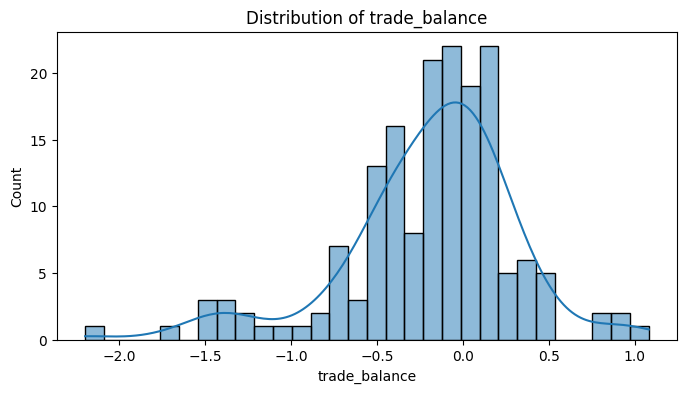

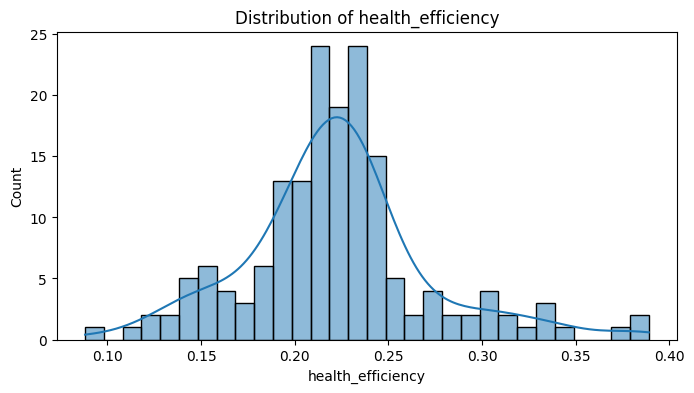

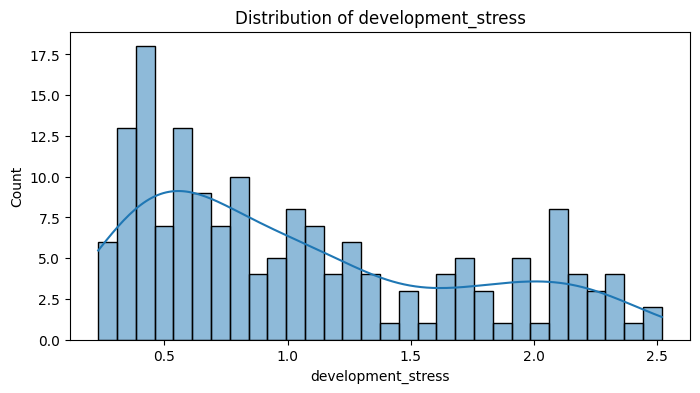

In [48]:
# Engineered feature distributions

engineered_cols = [
    'trade_balance',
    'health_efficiency',
    'development_stress'
]

for col in engineered_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.histplot(
        df_fe[col],
        kde=True,
        bins=30
    )
    
    plt.title(f'Distribution of {col}')
    
    plt.show()

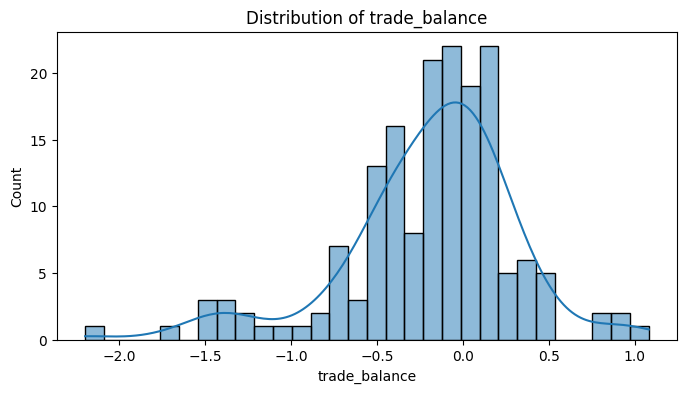

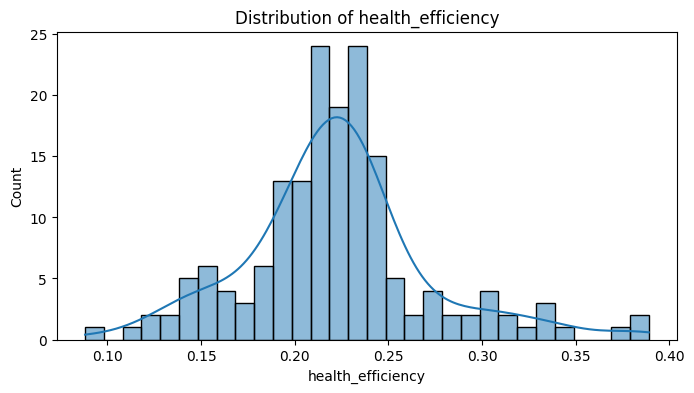

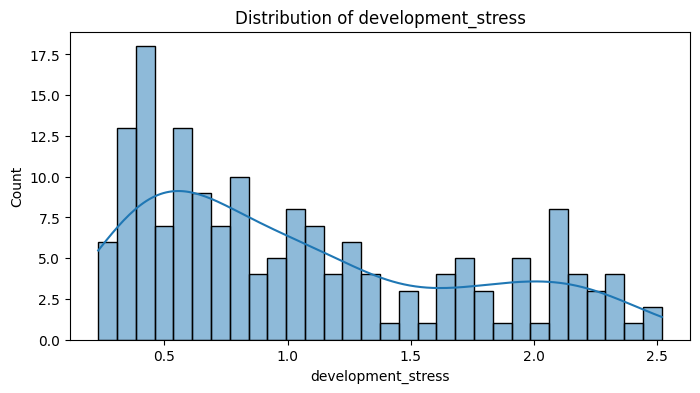

In [49]:
# Engineered feature distributions

engineered_cols = [
    'trade_balance',
    'health_efficiency',
    'development_stress'
]

for col in engineered_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.histplot(
        df_fe[col],
        kde=True,
        bins=30
    )
    
    plt.title(f'Distribution of {col}')
    
    plt.show()

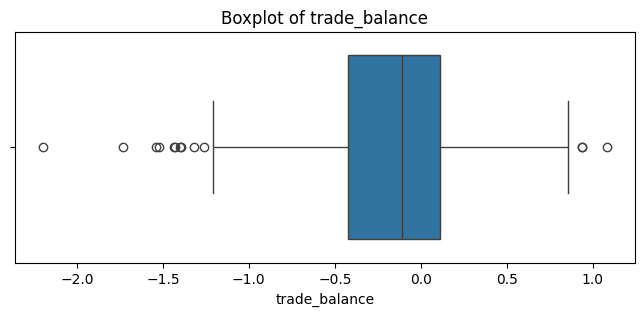

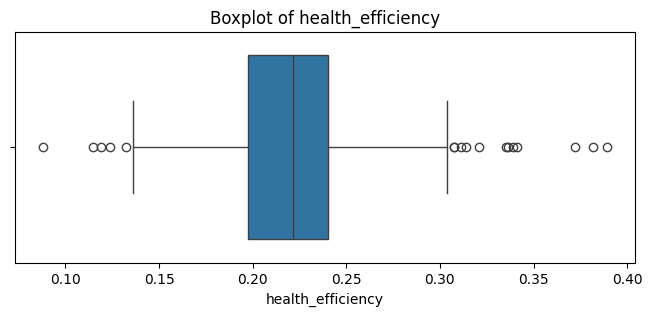

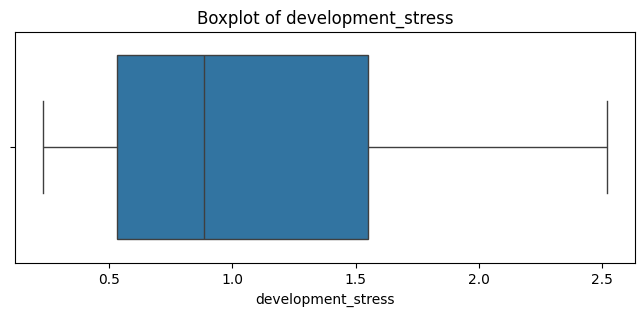

In [50]:
# Boxplots for engineered features

for col in engineered_cols:
    
    plt.figure(figsize=(8,3))
    
    sns.boxplot(x=df_fe[col])
    
    plt.title(f'Boxplot of {col}')
    
    plt.show()

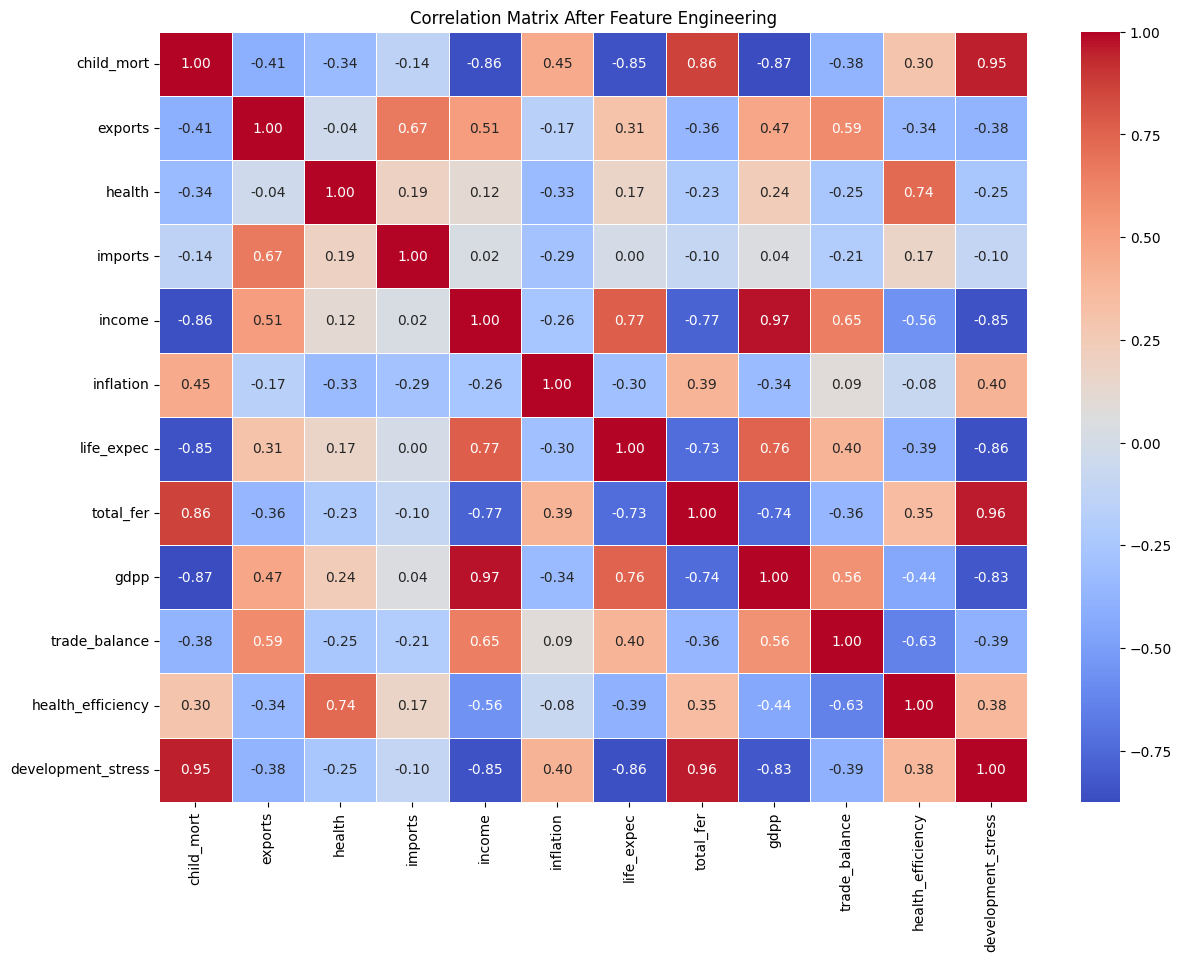

In [51]:
# Correlation matrix with engineered features

plt.figure(figsize=(14,10))

sns.heatmap(
    df_fe.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Matrix After Feature Engineering")

plt.show()

In [52]:
# Correlation of engineered features only

df_fe[engineered_cols].corr()

,trade_balance,health_efficiency,development_stress
trade_balance,1.000000,-0.633629,-0.390826
health_efficiency,-0.633629,1.000000,0.375623
development_stress,-0.390826,0.375623,1.000000


In [53]:
df_fe.drop(columns=['development_stress'], inplace=True)

In [54]:
# Final feature list

print("Final Features:")
print(df_fe.columns.tolist())

print("\nShape:")
print(df_fe.shape)

Final Features:
['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp', 'trade_balance', 'health_efficiency']

Shape:
(167, 11)


****PHASE 5: FEATURE SCALING****

In [55]:
# Final feature matrix

X = df_fe.copy()

print(X.shape)

X.head()

(167, 11)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,trade_balance,health_efficiency
0,4.513055,2.397895,2.149434,3.826465,7.384610,2.750471,4.046554,1.919859,6.317165,-1.428570,0.291069
1,2.867899,3.367296,2.021548,3.903991,9.203416,2.370244,4.347694,0.974560,8.316545,-0.536695,0.219652
2,3.342862,3.673766,1.642873,3.478158,9.465060,3.105035,4.350278,1.358409,8.403128,0.195607,0.173572
3,4.787492,4.147885,1.348073,3.781914,8.682877,3.353756,4.112512,1.968510,8.169336,0.365971,0.155257
4,2.424803,3.839452,1.950187,4.092677,9.857496,2.034706,4.354141,1.141033,9.409273,-0.253224,0.197838


In [56]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Scale features
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 1.27801205, -1.7643134 ,  0.43464558,  0.14786752, -1.41303458,
         0.50922678, -1.58159894,  1.73481749, -1.46030093, -2.47295402,
         1.40210037],
       [-0.23970754, -0.28387175,  0.07648044,  0.29183453,  0.07165967,
        -0.20353314,  0.63084985, -0.94433634, -0.12283509, -0.68693702,
        -0.05739174],
       [ 0.19846398,  0.18416071, -0.98405604, -0.49894589,  0.2852398 ,
         1.17387962,  0.64983413,  0.14356389, -0.06491589,  0.77952943,
        -0.99907523],
       [ 1.53119057,  0.90822288, -1.80968692,  0.06513568, -0.35325741,
         1.64012345, -1.09701171,  1.87270199, -0.22130867,  1.12068976,
        -1.37337876],
       [-0.64848077,  0.43719253, -0.12337648,  0.64222809,  0.60558581,
        -0.83252055,  0.67821887, -0.47252016,  0.608135  , -0.11927476,
        -0.50318222]])

In [57]:
# Convert scaled array to dataframe

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,trade_balance,health_efficiency
0,1.278012,-1.764313,0.434646,0.147868,-1.413035,0.509227,-1.581599,1.734817,-1.460301,-2.472954,1.402100
1,-0.239708,-0.283872,0.076480,0.291835,0.071660,-0.203533,0.630850,-0.944336,-0.122835,-0.686937,-0.057392
2,0.198464,0.184161,-0.984056,-0.498946,0.285240,1.173880,0.649834,0.143564,-0.064916,0.779529,-0.999075
3,1.531191,0.908223,-1.809687,0.065136,-0.353257,1.640123,-1.097012,1.872702,-0.221309,1.120690,-1.373379
4,-0.648481,0.437193,-0.123376,0.642228,0.605586,-0.832521,0.678219,-0.472520,0.608135,-0.119275,-0.503182


In [58]:
# Mean and std validation

scaling_validation = pd.DataFrame({
    'Mean': X_scaled_df.mean(),
    'Std': X_scaled_df.std()
})

scaling_validation

,Mean,Std
child_mort,-7.844690e-17,1.003008
exports,-1.018480e-15,1.003008
health,-2.393295e-17,1.003008
imports,2.871954e-16,1.003008
income,3.324021e-16,1.003008
inflation,-3.696311e-16,1.003008
life_expec,1.382793e-15,1.003008
total_fer,7.592064e-16,1.003008
gdpp,-4.254747e-16,1.003008
trade_balance,-3.722904e-17,1.003008


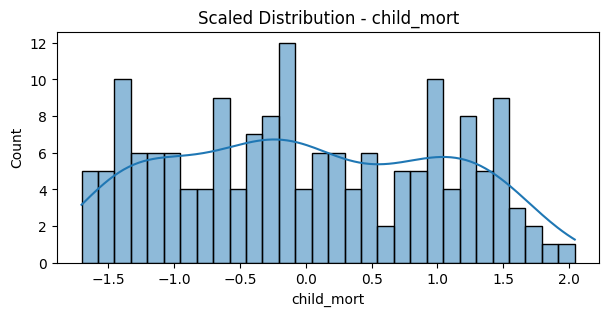

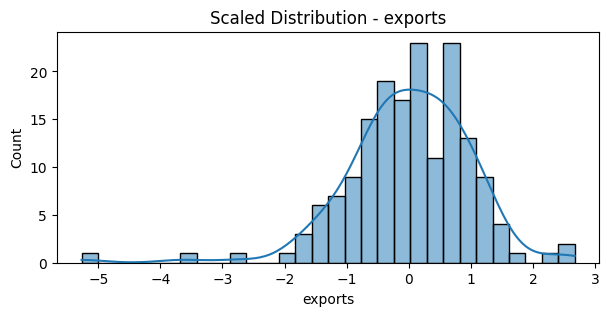

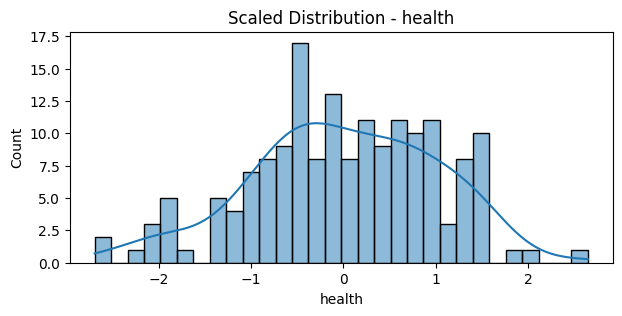

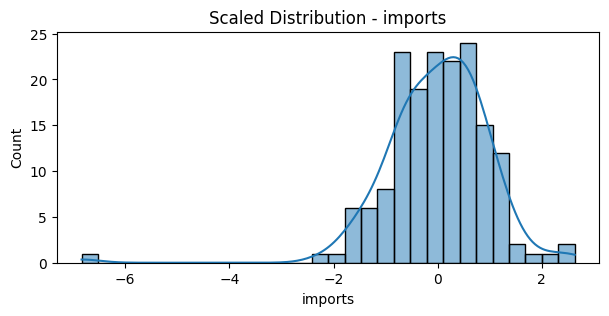

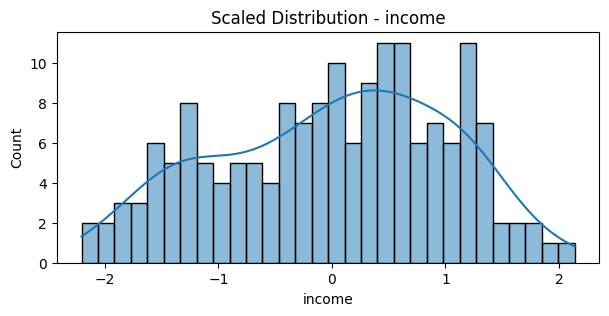

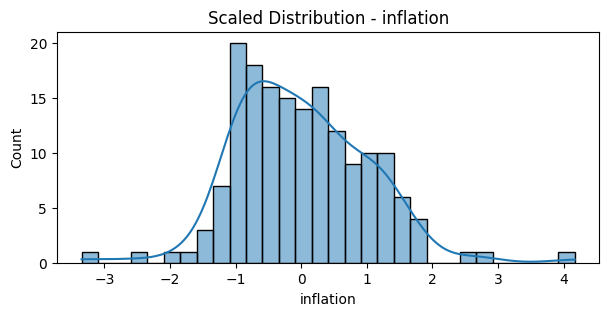

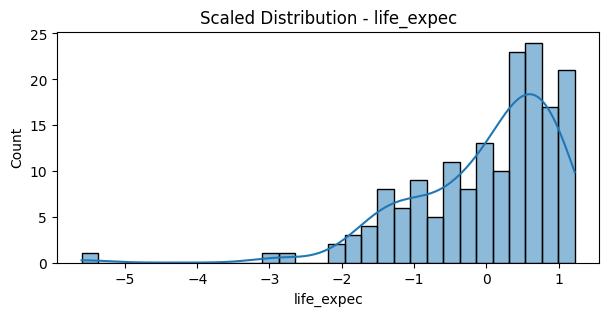

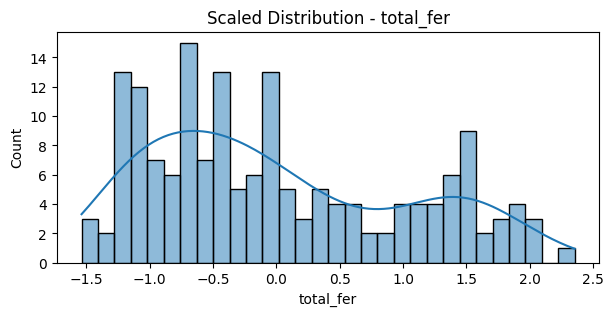

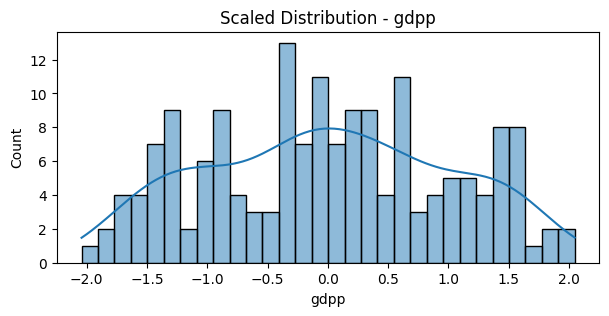

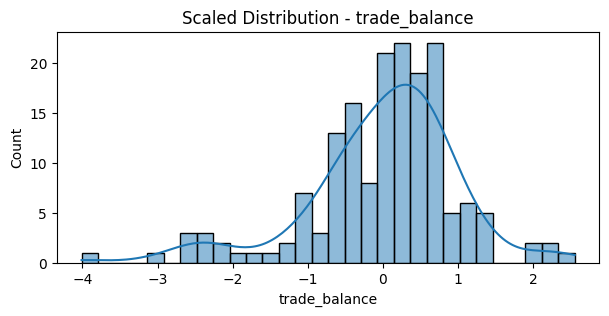

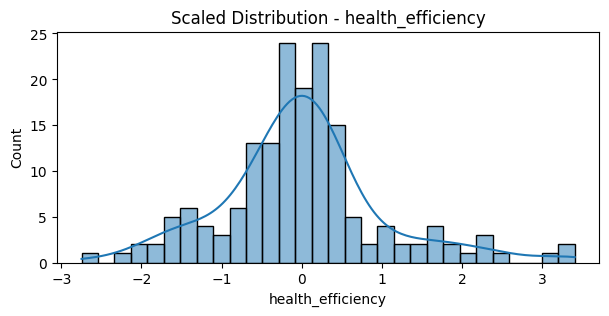

In [59]:
# Distribution after scaling

for col in X_scaled_df.columns:
    
    plt.figure(figsize=(7,3))
    
    sns.histplot(
        X_scaled_df[col],
        kde=True,
        bins=30
    )
    
    plt.title(f'Scaled Distribution - {col}')
    
    plt.show()

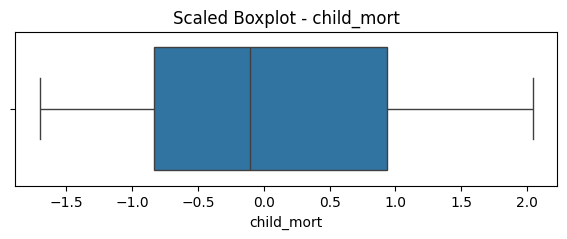

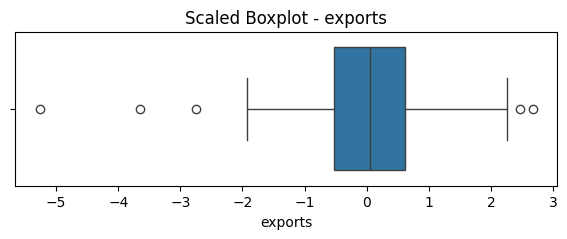

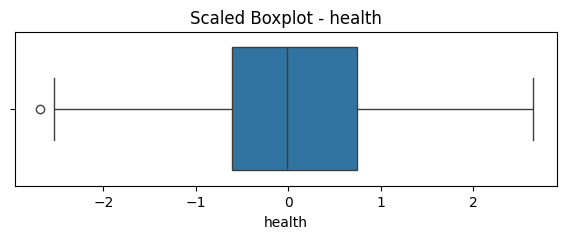

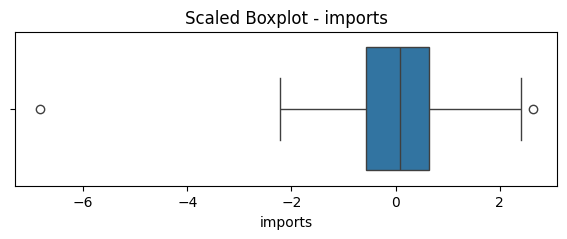

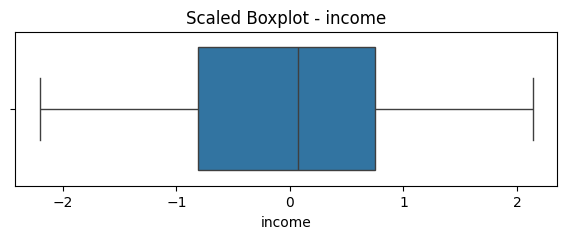

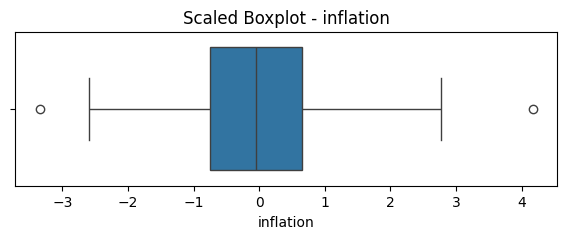

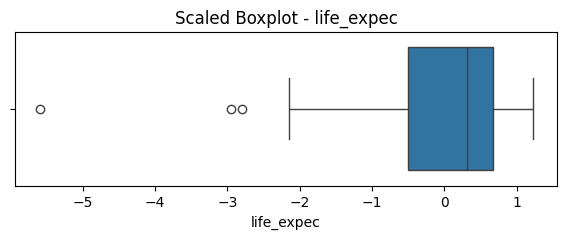

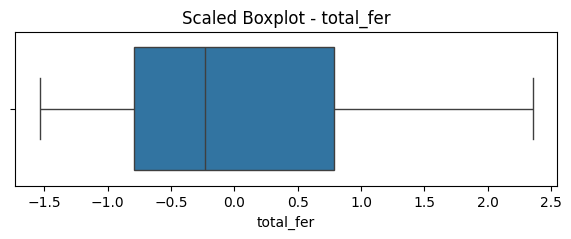

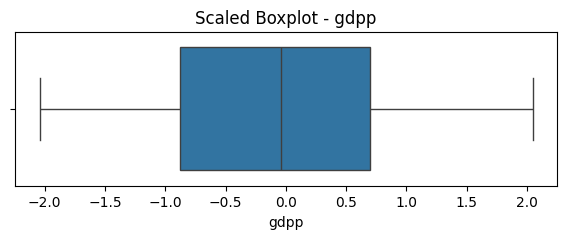

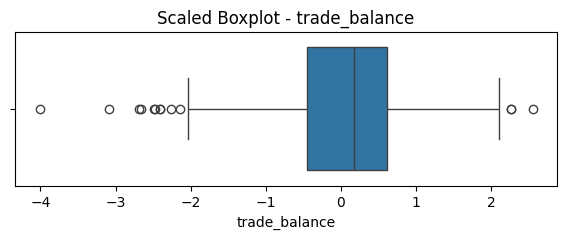

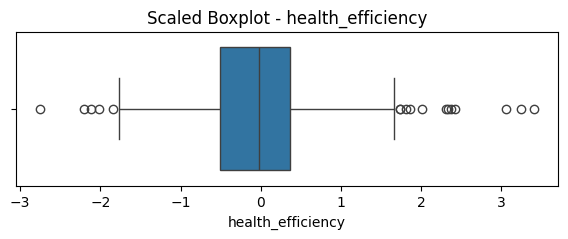

In [60]:
# Boxplots after scaling

for col in X_scaled_df.columns:
    
    plt.figure(figsize=(7,2))
    
    sns.boxplot(
        x=X_scaled_df[col]
    )
    
    plt.title(f'Scaled Boxplot - {col}')
    
    plt.show()

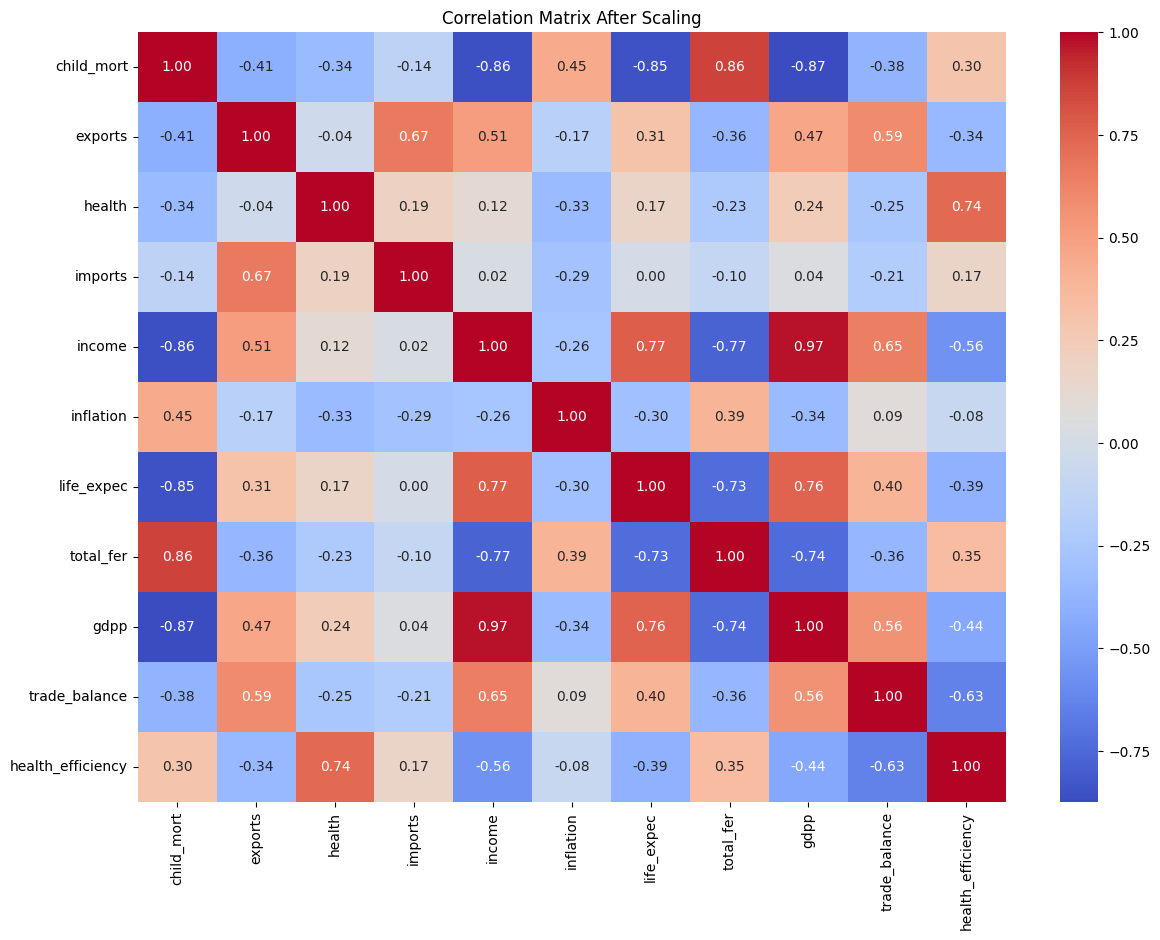

In [61]:
# Correlation check after scaling

plt.figure(figsize=(14,10))

sns.heatmap(
    X_scaled_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix After Scaling")

plt.show()

In [62]:
print("Scaled Dataset Shape:")
print(X_scaled_df.shape)

print("\nAny Nulls?")
print(X_scaled_df.isnull().sum().sum())

print("\nFeature Means:")
print(np.round(X_scaled_df.mean(), 4))

print("\nFeature Std Dev:")
print(np.round(X_scaled_df.std(), 4))

Scaled Dataset Shape:
(167, 11)

Any Nulls?
0

Feature Means:
child_mort          -0.0
exports             -0.0
health              -0.0
imports              0.0
income               0.0
inflation           -0.0
life_expec           0.0
total_fer            0.0
gdpp                -0.0
trade_balance       -0.0
health_efficiency   -0.0
dtype: float64

Feature Std Dev:
child_mort           1.003
exports              1.003
health               1.003
imports              1.003
income               1.003
inflation            1.003
life_expec           1.003
total_fer            1.003
gdpp                 1.003
trade_balance        1.003
health_efficiency    1.003
dtype: float64


****PHASE 6: PCA****

In [63]:
# Fit PCA with all possible components

pca_full = PCA()
pca_full.fit(X_scaled_df)

PCA()

In [64]:
# Explained variance ratio

explained_variance = pca_full.explained_variance_ratio_
explained_variance

array([0.48346815, 0.20793233, 0.13495867, 0.0718697 , 0.04697803,
       0.02359375, 0.02292261, 0.00584411, 0.00142487, 0.00100778,
       0.        ])

In [65]:
# Cumulative explained variance

cumulative_variance = np.cumsum(explained_variance)
cumulative_variance

array([0.48346815, 0.69140048, 0.82635914, 0.89822884, 0.94520687,
       0.96880063, 0.99172324, 0.99756735, 0.99899222, 1.        ,
       1.        ])

In [66]:
# Variance summary dataframe

pca_variance_df = pd.DataFrame({
    'Principal Component': [
        f'PC{i+1}'
        for i in range(len(explained_variance))
    ],
    'Explained Variance Ratio': explained_variance,
    'Cumulative Variance': cumulative_variance
})

pca_variance_df

,Principal Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.483468,0.483468
1,PC2,0.207932,0.691400
2,PC3,0.134959,0.826359
3,PC4,0.071870,0.898229
4,PC5,0.046978,0.945207
5,PC6,0.023594,0.968801
6,PC7,0.022923,0.991723
7,PC8,0.005844,0.997567
8,PC9,0.001425,0.998992
9,PC10,0.001008,1.000000


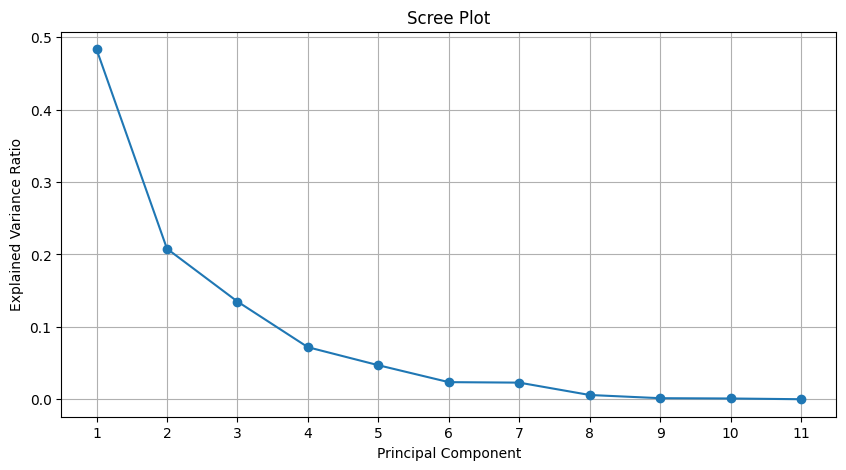

In [67]:
# Scree plot

plt.figure(figsize=(10,5))

plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance,
    marker='o'
)

plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')

plt.title('Scree Plot')

plt.xticks(
    range(1, len(explained_variance)+1)
)

plt.grid(True)

plt.show()

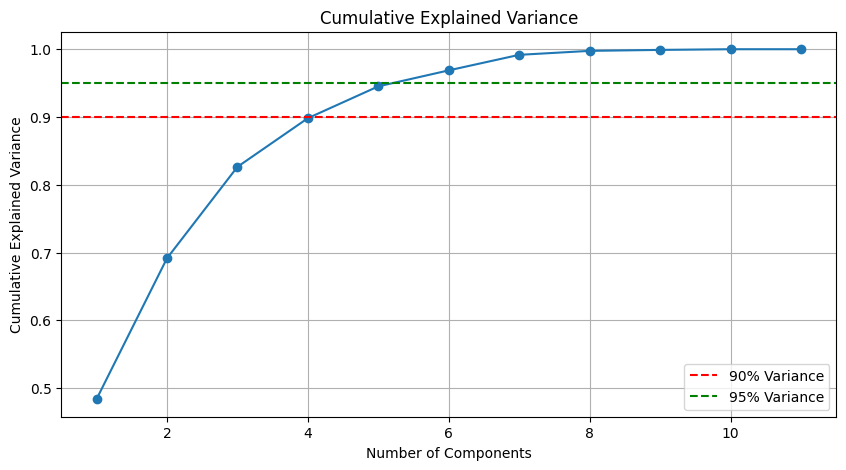

In [68]:
# Cumulative explained variance plot

plt.figure(figsize=(10,5))

plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker='o'
)

plt.axhline(
    y=0.90,
    color='r',
    linestyle='--',
    label='90% Variance'
)

plt.axhline(
    y=0.95,
    color='g',
    linestyle='--',
    label='95% Variance'
)

plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')

plt.title('Cumulative Explained Variance')

plt.legend()

plt.grid(True)

plt.show()

In [69]:
# Find components for 90% variance

n_components_90 = np.argmax(
    cumulative_variance >= 0.90
) + 1

# Find components for 95% variance

n_components_95 = np.argmax(
    cumulative_variance >= 0.95
) + 1

print("Components for 90% variance:", n_components_90)
print("Components for 95% variance:", n_components_95)

Components for 90% variance: 5
Components for 95% variance: 6


In [70]:
# Final PCA

pca = PCA(
    n_components=5,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled_df)

In [71]:
# PCA dataframe

pca_columns = [
    'PC1',
    'PC2',
    'PC3',
    'PC4',
    'PC5'
]

X_pca_df = pd.DataFrame(
    X_pca,
    columns=pca_columns
)

X_pca_df.head()

,PC1,PC2,PC3,PC4,PC5
0,-4.427617,1.331055,-0.461328,-0.279014,0.592913
1,0.460908,0.607901,-0.295108,-0.664052,0.823097
2,0.413018,-1.988689,-0.077479,0.337985,0.546645
3,-1.449168,-3.272375,1.722774,0.703350,-0.317345
4,1.547382,0.386376,0.421607,-0.769771,0.129424


In [72]:
# Final PCA variance summary

final_pca_variance = pd.DataFrame({
    'Component': pca_columns,
    'Explained Variance': pca.explained_variance_ratio_,
    'Cumulative Variance': np.cumsum(
        pca.explained_variance_ratio_
    )
})

final_pca_variance

,Component,Explained Variance,Cumulative Variance
0,PC1,0.483468,0.483468
1,PC2,0.207932,0.691400
2,PC3,0.134959,0.826359
3,PC4,0.071870,0.898229
4,PC5,0.046978,0.945207


In [73]:
# PCA loadings

loadings = pd.DataFrame(
    pca.components_.T,
    columns=pca_columns,
    index=X_scaled_df.columns
)

loadings

,PC1,PC2,PC3,PC4,PC5
child_mort,-0.399626,-0.166257,0.122651,0.038839,-0.171864
exports,0.258532,-0.032172,0.629651,0.223120,-0.115583
health,0.057100,0.574284,-0.171281,0.462607,-0.124053
imports,0.058747,0.302275,0.691848,-0.088534,0.315500
income,0.416653,-0.053254,-0.073482,0.108423,-0.018697
inflation,-0.165841,-0.370841,-0.039439,0.637912,0.640251
life_expec,0.365716,0.045874,-0.192882,-0.077046,0.342624
total_fer,-0.369139,-0.112827,0.125237,0.136739,-0.242601
gdpp,0.406575,0.033333,-0.100533,0.120836,-0.084886
trade_balance,0.275657,-0.368147,0.079582,0.388043,-0.491784


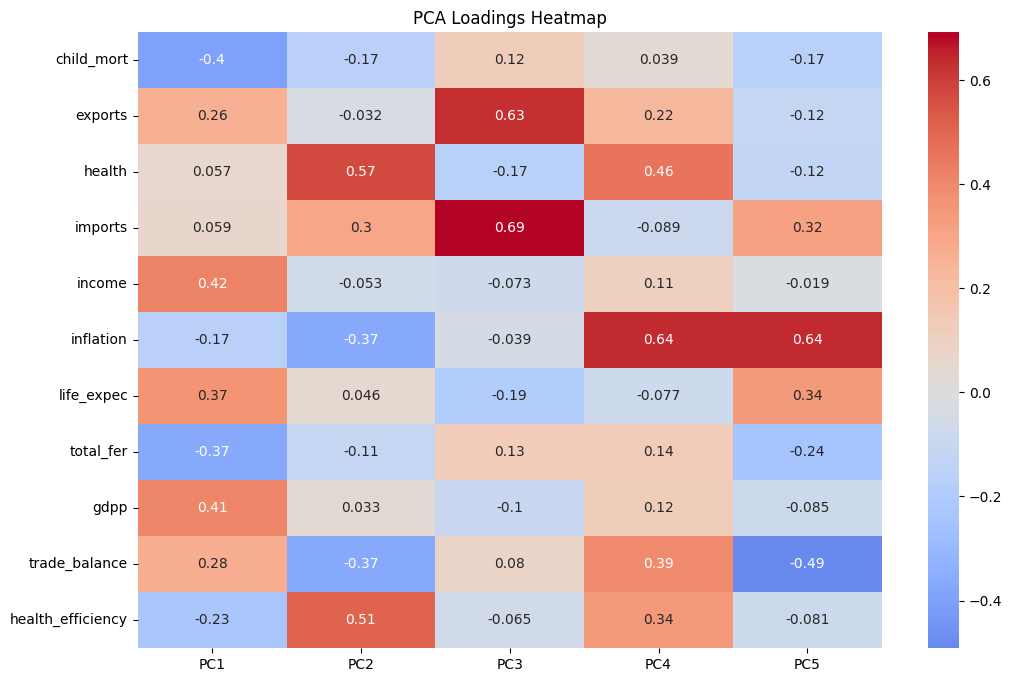

In [74]:
plt.figure(figsize=(12,8))

sns.heatmap(
    loadings,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title('PCA Loadings Heatmap')

plt.show()

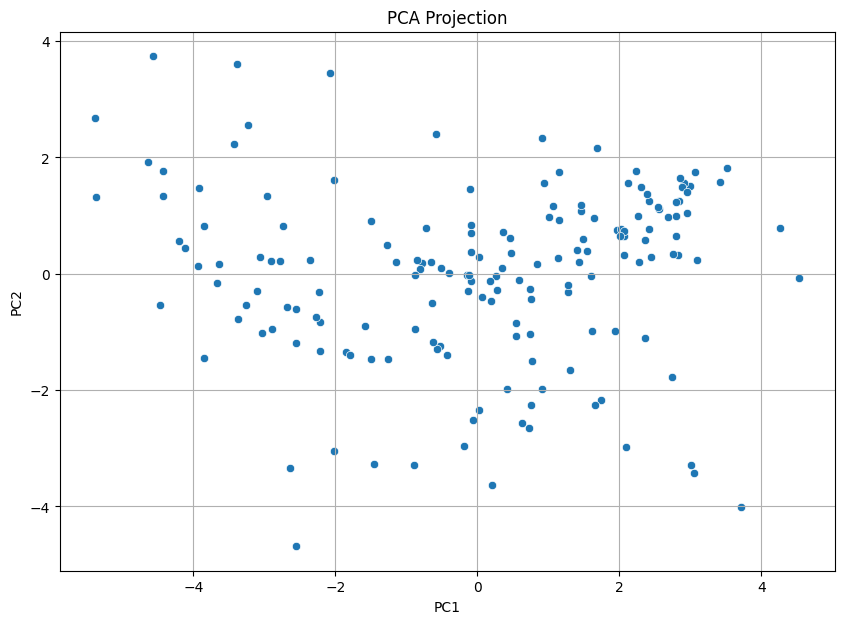

In [75]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x=X_pca_df['PC1'],
    y=X_pca_df['PC2']
)

plt.title('PCA Projection')

plt.xlabel('PC1')
plt.ylabel('PC2')

plt.grid(True)

plt.show()

In [76]:
X_final = X_pca_df.copy()

X_final.head()

,PC1,PC2,PC3,PC4,PC5
0,-4.427617,1.331055,-0.461328,-0.279014,0.592913
1,0.460908,0.607901,-0.295108,-0.664052,0.823097
2,0.413018,-1.988689,-0.077479,0.337985,0.546645
3,-1.449168,-3.272375,1.722774,0.703350,-0.317345
4,1.547382,0.386376,0.421607,-0.769771,0.129424


****PHASE 7: KMEANS CLUSTERING****

In [77]:
inertia = []
silhouette_scores = []

K_range = range(2, 11)

for k in K_range:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_final)
    
    inertia.append(kmeans.inertia_)
    
    silhouette_scores.append(
        silhouette_score(X_final, labels)
    )

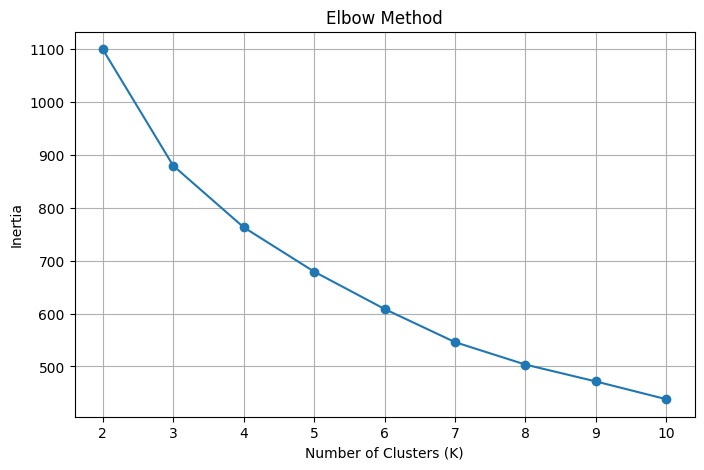

In [78]:
plt.figure(figsize=(8,5))

plt.plot(
    K_range,
    inertia,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.title('Elbow Method')

plt.grid(True)

plt.show()

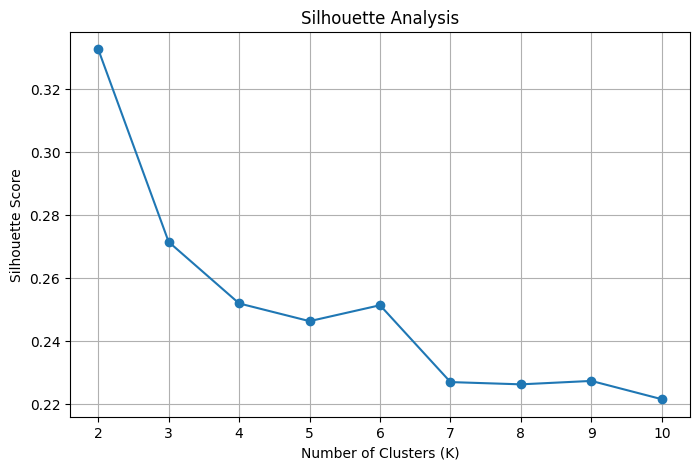

In [79]:
plt.figure(figsize=(8,5))

plt.plot(
    K_range,
    silhouette_scores,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')

plt.title('Silhouette Analysis')

plt.grid(True)

plt.show()

In [80]:
kmeans_results = pd.DataFrame({
    'K': list(K_range),
    'Inertia': inertia,
    'Silhouette Score': silhouette_scores
})

kmeans_results

,K,Inertia,Silhouette Score
0,2,1099.110100,0.332746
1,3,879.256258,0.271432
2,4,762.933473,0.251858
3,5,679.166590,0.246214
4,6,608.603797,0.251284
5,7,545.996834,0.226827
6,8,503.596915,0.226108
7,9,471.759511,0.227197
8,10,438.187776,0.221374


In [81]:
optimal_k = 3

# Final KMeans model

kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

kmeans_clusters = kmeans_final.fit_predict(X_final)

In [82]:
# Cluster labels

kmeans_clusters[:10]

array([2, 1, 0, 0, 1, 0, 0, 1, 1, 0], dtype=int32)

In [83]:
# Add cluster labels

X_pca_df['KMeans_Cluster'] = kmeans_clusters

X_pca_df.head()

,PC1,PC2,PC3,PC4,PC5,KMeans_Cluster
0,-4.427617,1.331055,-0.461328,-0.279014,0.592913,2
1,0.460908,0.607901,-0.295108,-0.664052,0.823097,1
2,0.413018,-1.988689,-0.077479,0.337985,0.546645,0
3,-1.449168,-3.272375,1.722774,0.703350,-0.317345,0
4,1.547382,0.386376,0.421607,-0.769771,0.129424,1


In [84]:
# Number of countries per cluster

X_pca_df['KMeans_Cluster'].value_counts()

KMeans_Cluster
0    68
1    60
2    39
Name: count, dtype: int64

In [85]:
# Cluster centers

cluster_centers = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=X_final.columns
)

cluster_centers

,PC1,PC2,PC3,PC4,PC5
0,0.046521,-1.195717,0.019109,0.104178,0.154257
1,2.086788,0.949084,-0.142928,-0.057549,-0.094399
2,-3.291557,0.624712,0.186571,-0.093108,-0.123732


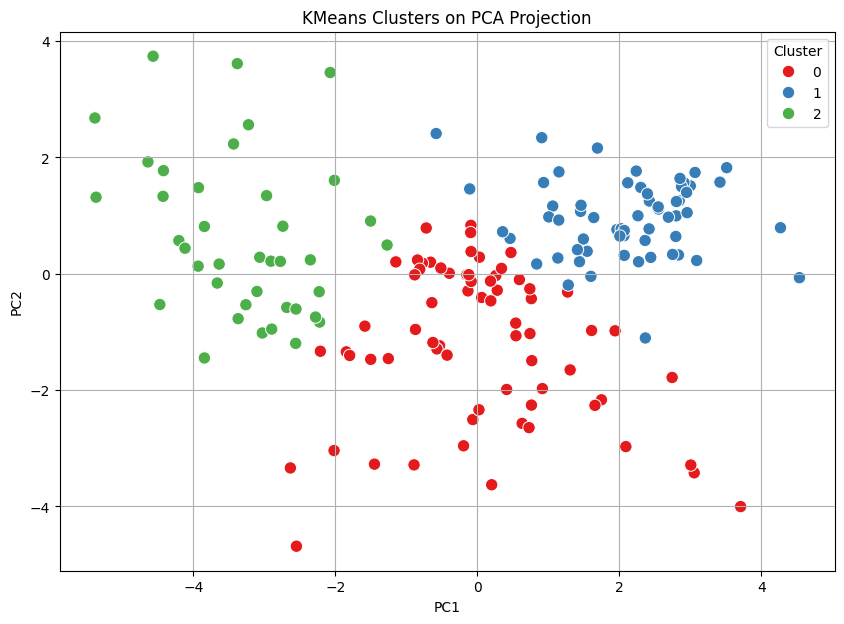

In [86]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x=X_pca_df['PC1'],
    y=X_pca_df['PC2'],
    hue=X_pca_df['KMeans_Cluster'],
    palette='Set1',
    s=80
)

plt.title('KMeans Clusters on PCA Projection')

plt.xlabel('PC1')
plt.ylabel('PC2')

plt.grid(True)

plt.legend(title='Cluster')

plt.show()

In [87]:
kmeans_result_df = X_pca_df.copy()

kmeans_result_df.head()

,PC1,PC2,PC3,PC4,PC5,KMeans_Cluster
0,-4.427617,1.331055,-0.461328,-0.279014,0.592913,2
1,0.460908,0.607901,-0.295108,-0.664052,0.823097,1
2,0.413018,-1.988689,-0.077479,0.337985,0.546645,0
3,-1.449168,-3.272375,1.722774,0.703350,-0.317345,0
4,1.547382,0.386376,0.421607,-0.769771,0.129424,1


****PHASE 8: DBSCAN****

In [88]:
# Nearest neighbors

neighbors = NearestNeighbors(
    n_neighbors=10
)

neighbors_fit = neighbors.fit(X_final)

distances, indices = neighbors_fit.kneighbors(X_final)

In [89]:
# Sort kth-neighbor distances

distances = np.sort(
    distances[:, -1]
)

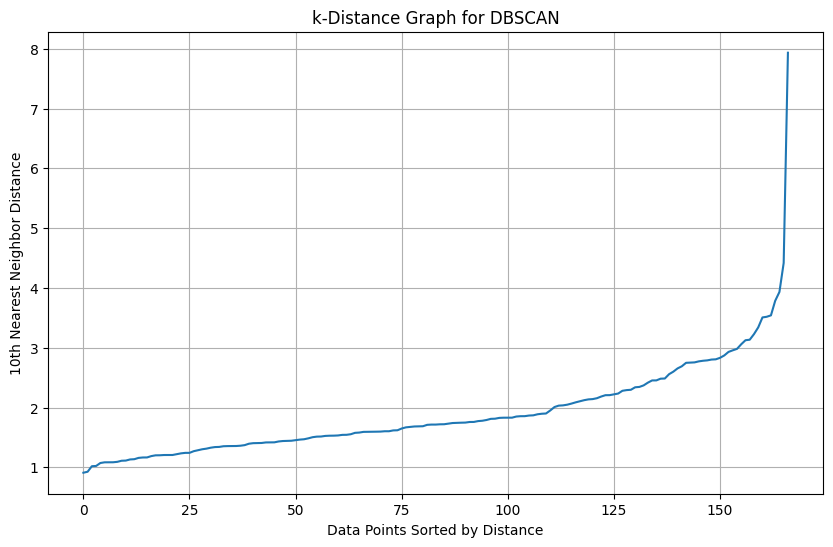

In [90]:
plt.figure(figsize=(10,6))

plt.plot(distances)

plt.title('k-Distance Graph for DBSCAN')

plt.xlabel('Data Points Sorted by Distance')
plt.ylabel('10th Nearest Neighbor Distance')

plt.grid(True)

plt.show()

In [91]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

dbscan_results = []

eps_values = np.arange(0.8, 2.3, 0.1)

for eps in eps_values:
    
    dbscan = DBSCAN(
        eps=eps,
        min_samples=10
    )
    
    labels = dbscan.fit_predict(X_final)
    
    # Count clusters excluding noise
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    # Count noise points
    noise_points = list(labels).count(-1)
    
    # Remove noise points for silhouette score
    mask = labels != -1
    
    filtered_data = X_final[mask]
    filtered_labels = labels[mask]
    
    # Valid silhouette condition
    if n_clusters > 1 and len(set(filtered_labels)) > 1:
        
        score = silhouette_score(
            filtered_data,
            filtered_labels
        )
        
    else:
        score = -1
    
    dbscan_results.append([
        eps,
        n_clusters,
        noise_points,
        score
    ])

In [92]:
dbscan_results_df = pd.DataFrame(
    dbscan_results,
    columns=[
        'eps',
        'Clusters',
        'Noise Points',
        'Silhouette Score'
    ]
)

dbscan_results_df

,eps,Clusters,Noise Points,Silhouette Score
0,0.8,0,167,-1.000000
1,0.9,0,167,-1.000000
2,1.0,2,145,0.478481
3,1.1,1,131,-1.000000
4,1.2,1,122,-1.000000
5,1.3,2,108,0.281210
6,1.4,2,88,0.511067
7,1.5,2,68,0.446535
8,1.6,1,51,-1.000000
9,1.7,1,45,-1.000000


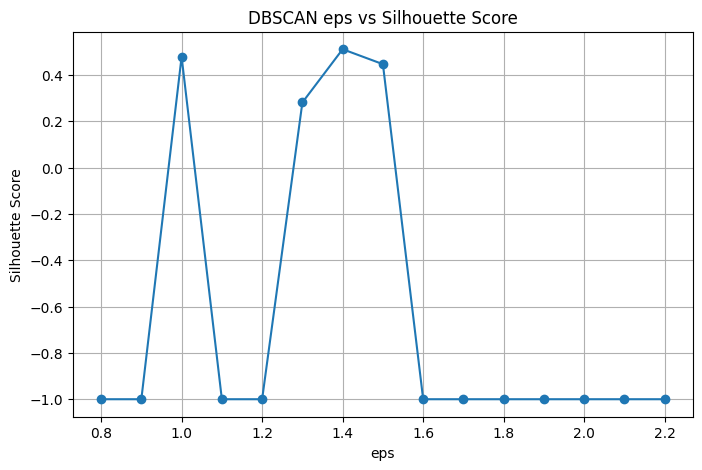

In [93]:
plt.figure(figsize=(8,5))

plt.plot(
    dbscan_results_df['eps'],
    dbscan_results_df['Silhouette Score'],
    marker='o'
)

plt.xlabel('eps')
plt.ylabel('Silhouette Score')

plt.title('DBSCAN eps vs Silhouette Score')

plt.grid(True)

plt.show()

In [94]:
eps = 1.5
min_samples = 5

In [95]:
# Final DBSCAN model
dbscan = DBSCAN(eps=1.5, min_samples=5)

# Fit and predict
dbscan_labels = dbscan.fit_predict(X_pca_df)

# Create result dataframe
dbscan_result_df = X_pca_df.copy()

# Add cluster labels
dbscan_result_df['DBSCAN_Cluster'] = dbscan_labels

# View results
dbscan_result_df.head()

,PC1,PC2,PC3,PC4,PC5,KMeans_Cluster,DBSCAN_Cluster
0,-4.427617,1.331055,-0.461328,-0.279014,0.592913,2,-1
1,0.460908,0.607901,-0.295108,-0.664052,0.823097,1,0
2,0.413018,-1.988689,-0.077479,0.337985,0.546645,0,0
3,-1.449168,-3.272375,1.722774,0.703350,-0.317345,0,-1
4,1.547382,0.386376,0.421607,-0.769771,0.129424,1,0


In [96]:
print(dbscan_result_df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    104
-1     44
 1     19
Name: count, dtype: int64


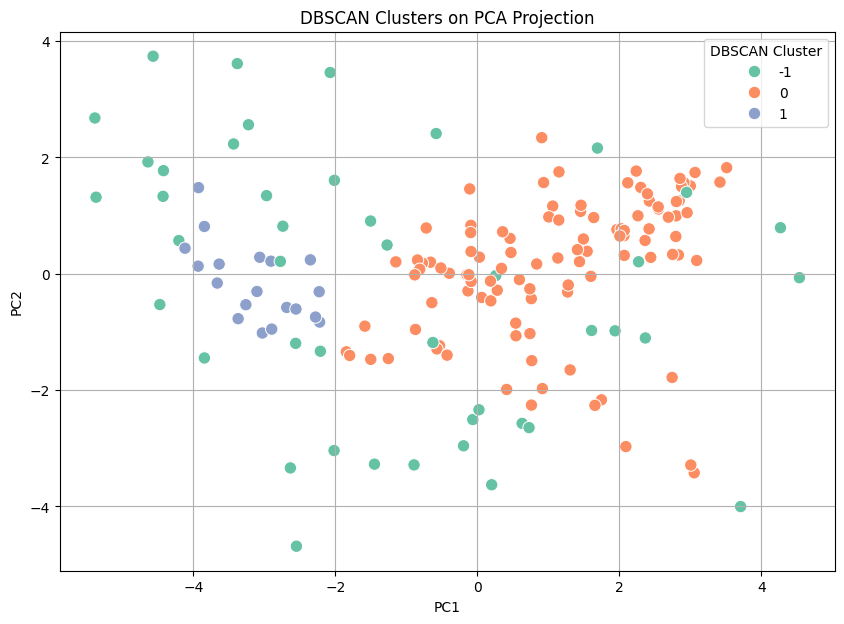

In [97]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=dbscan_result_df,
    x='PC1',
    y='PC2',
    hue='DBSCAN_Cluster',
    palette='Set2',
    s=80
)

plt.title('DBSCAN Clusters on PCA Projection')

plt.xlabel('PC1')
plt.ylabel('PC2')

plt.grid(True)

plt.legend(title='DBSCAN Cluster')

plt.show()

In [98]:
# Number of noise points

noise_count = (
    dbscan_result_df['DBSCAN_Cluster'] == -1
).sum()

print("Noise Points:", noise_count)

Noise Points: 44


In [99]:
# Percentage of noise points

noise_percentage = (
    noise_count / len(dbscan_result_df)
) * 100

print(f"Noise Percentage: {noise_percentage:.2f}%")

Noise Percentage: 26.35%


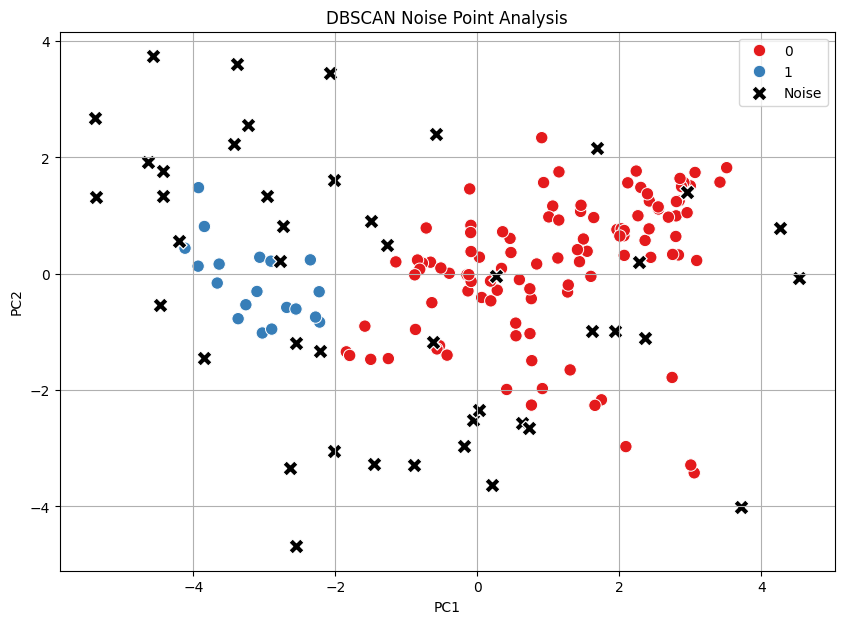

In [100]:
# Highlight noise points

plt.figure(figsize=(10,7))

# Core clusters
sns.scatterplot(
    data=dbscan_result_df[
        dbscan_result_df['DBSCAN_Cluster'] != -1
    ],
    x='PC1',
    y='PC2',
    hue='DBSCAN_Cluster',
    palette='Set1',
    s=80
)

# Noise points
sns.scatterplot(
    data=dbscan_result_df[
        dbscan_result_df['DBSCAN_Cluster'] == -1
    ],
    x='PC1',
    y='PC2',
    color='black',
    marker='X',
    s=120,
    label='Noise'
)

plt.title('DBSCAN Noise Point Analysis')

plt.grid(True)

plt.show()

****PHASE 9: CLUSTER EVALUATION****

In [101]:
# KMeans labels
kmeans_labels = kmeans_result_df['KMeans_Cluster']

# Metrics
kmeans_silhouette = silhouette_score(
    X_pca_df,
    kmeans_labels
)

kmeans_dbi = davies_bouldin_score(
    X_pca_df,
    kmeans_labels
)

kmeans_chs = calinski_harabasz_score(
    X_pca_df,
    kmeans_labels
)

print("KMeans Evaluation")
print("Silhouette Score:", round(kmeans_silhouette, 3))
print("Davies-Bouldin Index:", round(kmeans_dbi, 3))
print("Calinski-Harabasz Score:", round(kmeans_chs, 3))

KMeans Evaluation
Silhouette Score: 0.313
Davies-Bouldin Index: 1.204
Calinski-Harabasz Score: 89.442


In [102]:
# Remove noise points
mask = dbscan_result_df['DBSCAN_Cluster'] != -1

X_dbscan = X_pca_df[mask]

dbscan_labels = dbscan_result_df.loc[
    mask,
    'DBSCAN_Cluster'
]

# Metrics
dbscan_silhouette = silhouette_score(
    X_dbscan,
    dbscan_labels
)

dbscan_dbi = davies_bouldin_score(
    X_dbscan,
    dbscan_labels
)

dbscan_chs = calinski_harabasz_score(
    X_dbscan,
    dbscan_labels
)

print("DBSCAN Evaluation")
print("Silhouette Score:", round(dbscan_silhouette, 3))
print("Davies-Bouldin Index:", round(dbscan_dbi, 3))
print("Calinski-Harabasz Score:", round(dbscan_chs, 3))

DBSCAN Evaluation
Silhouette Score: 0.421
Davies-Bouldin Index: 0.765
Calinski-Harabasz Score: 70.336


In [103]:
evaluation_df = pd.DataFrame({
    'Model': ['KMeans', 'DBSCAN'],
    'Silhouette Score': [
        kmeans_silhouette,
        dbscan_silhouette
    ],
    'Davies-Bouldin Index': [
        kmeans_dbi,
        dbscan_dbi
    ],
    'Calinski-Harabasz Score': [
        kmeans_chs,
        dbscan_chs
    ]
})

evaluation_df

,Model,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score
0,KMeans,0.313144,1.204088,89.441880
1,DBSCAN,0.421346,0.765033,70.335744


****PHASE 11: CLUSTER EVALUATION****

In [104]:
# Create interpretation dataframe

cluster_interpretation_df = X_scaled_df.copy()

# Add KMeans cluster labels
cluster_interpretation_df['Cluster'] = kmeans_result_df['KMeans_Cluster']
cluster_interpretation_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,trade_balance,health_efficiency,Cluster
0,1.278012,-1.764313,0.434646,0.147868,-1.413035,0.509227,-1.581599,1.734817,-1.460301,-2.472954,1.402100,2
1,-0.239708,-0.283872,0.076480,0.291835,0.071660,-0.203533,0.630850,-0.944336,-0.122835,-0.686937,-0.057392,1
2,0.198464,0.184161,-0.984056,-0.498946,0.285240,1.173880,0.649834,0.143564,-0.064916,0.779529,-0.999075,0
3,1.531191,0.908223,-1.809687,0.065136,-0.353257,1.640123,-1.097012,1.872702,-0.221309,1.120690,-1.373379,0
4,-0.648481,0.437193,-0.123376,0.642228,0.605586,-0.832521,0.678219,-0.472520,0.608135,-0.119275,-0.503182,1


In [105]:
# Cluster-wise feature means

cluster_profile = cluster_interpretation_df.groupby('Cluster').mean()
cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,trade_balance,health_efficiency
Cluster,,,,,,,,,,,
0,0.225815,0.077849,-0.641521,-0.312099,0.084085,0.595529,0.021569,0.017659,-0.063749,0.438637,-0.596126
1,-1.021208,0.417098,0.677535,0.284391,0.812545,-0.787016,0.791698,-0.878517,0.892370,0.240254,-0.015080
2,1.177361,-0.777425,0.076188,0.106649,-1.396678,0.172434,-1.255604,1.320774,-1.261725,-1.134424,1.062600


In [106]:
# Rounded cluster profile

cluster_profile_rounded = cluster_profile.round(2)

cluster_profile_rounded

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,trade_balance,health_efficiency
Cluster,,,,,,,,,,,
0,0.23,0.08,-0.64,-0.31,0.08,0.60,0.02,0.02,-0.06,0.44,-0.60
1,-1.02,0.42,0.68,0.28,0.81,-0.79,0.79,-0.88,0.89,0.24,-0.02
2,1.18,-0.78,0.08,0.11,-1.40,0.17,-1.26,1.32,-1.26,-1.13,1.06


In [107]:
# Cluster distribution

cluster_counts = (
    cluster_interpretation_df['Cluster']
    .value_counts()
    .sort_index()
)

cluster_counts

Cluster
0    68
1    60
2    39
Name: count, dtype: int64

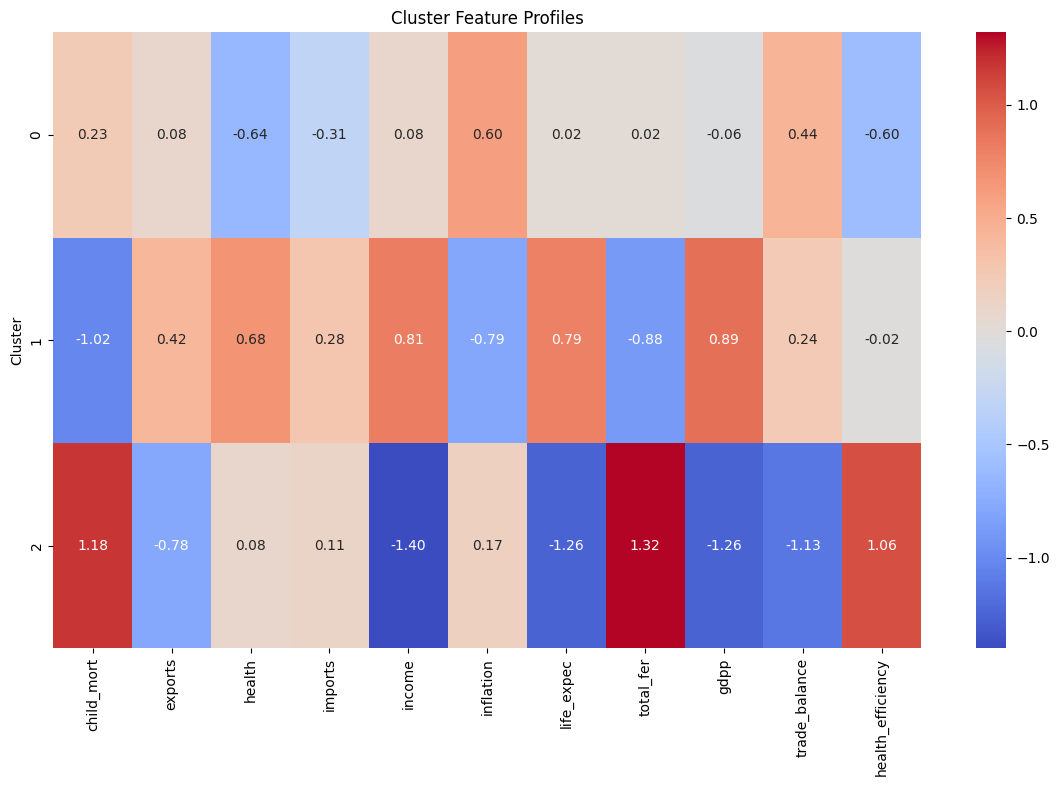

In [108]:
plt.figure(figsize=(14,8))

sns.heatmap(
    cluster_profile_rounded,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Cluster Feature Profiles')
plt.show()

In [109]:
original_cluster_df = df_fe.copy()

original_cluster_df['Cluster'] = (
    kmeans_result_df['KMeans_Cluster']
)

original_cluster_profile = (
    original_cluster_df
    .groupby('Cluster')
    .mean()
    .round(2)
)

original_cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,trade_balance,health_efficiency
Cluster,,,,,,,,,,,
0,3.37,3.60,1.77,3.58,9.22,2.80,4.26,1.31,8.40,0.03,0.19
1,2.02,3.83,2.24,3.90,10.11,2.06,4.37,1.00,9.83,-0.07,0.22
2,4.40,3.04,2.02,3.80,7.40,2.57,4.09,1.77,6.61,-0.76,0.27


- Cluster 0 → Developing
- Cluster 1 → Developed
- Cluster 2 → Underdeveloped

****PHASE 11: LABEL CREATION****

In [110]:
# Create meaningful labels from clusters

cluster_mapping = {
    0: 'Developing',
    1: 'Developed',
    2: 'Underdeveloped'
}

# Add final labels
kmeans_result_df['Country_Label'] = kmeans_result_df['KMeans_Cluster'].map(cluster_mapping)

# Preview
kmeans_result_df.head()

,PC1,PC2,PC3,PC4,PC5,KMeans_Cluster,Country_Label
0,-4.427617,1.331055,-0.461328,-0.279014,0.592913,2,Underdeveloped
1,0.460908,0.607901,-0.295108,-0.664052,0.823097,1,Developed
2,0.413018,-1.988689,-0.077479,0.337985,0.546645,0,Developing
3,-1.449168,-3.272375,1.722774,0.703350,-0.317345,0,Developing
4,1.547382,0.386376,0.421607,-0.769771,0.129424,1,Developed


In [111]:
# Check label distribution

kmeans_result_df['Country_Label'].value_counts()

Country_Label
Developing        68
Developed         60
Underdeveloped    39
Name: count, dtype: int64

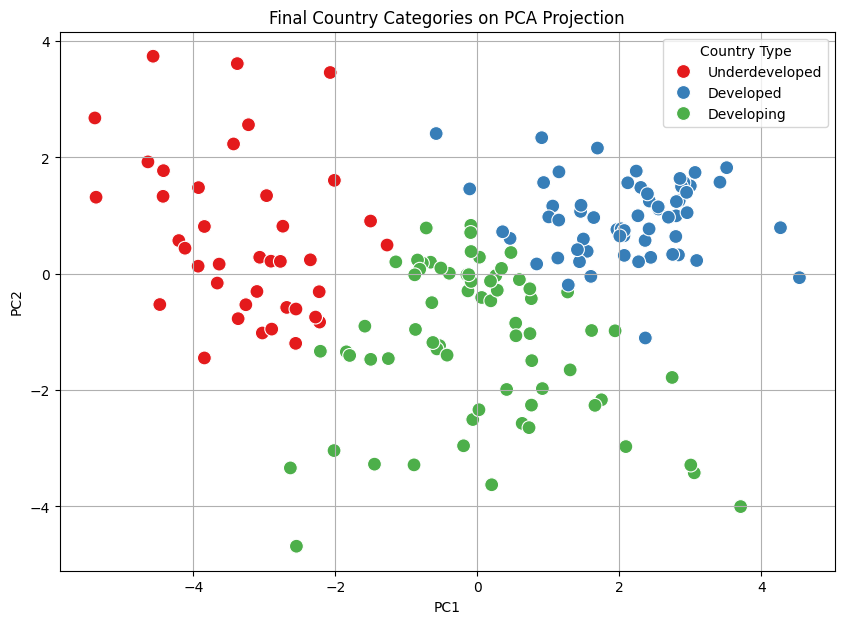

In [112]:
# Visualize final labeled clusters

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=kmeans_result_df,
    x='PC1',
    y='PC2',
    hue='Country_Label',
    palette='Set1',
    s=100
)

plt.title('Final Country Categories on PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Country Type')
plt.grid(True)

plt.show()

In [113]:
# Final labeled dataset preview

kmeans_result_df.head()

,PC1,PC2,PC3,PC4,PC5,KMeans_Cluster,Country_Label
0,-4.427617,1.331055,-0.461328,-0.279014,0.592913,2,Underdeveloped
1,0.460908,0.607901,-0.295108,-0.664052,0.823097,1,Developed
2,0.413018,-1.988689,-0.077479,0.337985,0.546645,0,Developing
3,-1.449168,-3.272375,1.722774,0.703350,-0.317345,0,Developing
4,1.547382,0.386376,0.421607,-0.769771,0.129424,1,Developed


****PHASE 12: CLASSIFICATION****

In [114]:
kmeans_result_df.columns

Index(['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'KMeans_Cluster', 'Country_Label'], dtype='object')

In [115]:
# Final supervised learning dataset

supervised_df = kmeans_result_df[
    ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'Country_Label']
]

supervised_df.head()

,PC1,PC2,PC3,PC4,PC5,Country_Label
0,-4.427617,1.331055,-0.461328,-0.279014,0.592913,Underdeveloped
1,0.460908,0.607901,-0.295108,-0.664052,0.823097,Developed
2,0.413018,-1.988689,-0.077479,0.337985,0.546645,Developing
3,-1.449168,-3.272375,1.722774,0.703350,-0.317345,Developing
4,1.547382,0.386376,0.421607,-0.769771,0.129424,Developed


In [116]:
# Features
X = supervised_df.drop(
    columns=['Country_Label']
)

# Target
y = supervised_df['Country_Label']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (167, 5)
Target Shape: (167,)


In [117]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [118]:
from sklearn.preprocessing import LabelEncoder

# Initialize encoder
label_encoder = LabelEncoder()

# Fit only on training labels
y_train_encoded = label_encoder.fit_transform(y_train)

# Transform test labels
y_test_encoded = label_encoder.transform(y_test)

In [119]:
label_mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)

print(label_mapping)

{'Developed': np.int64(0), 'Developing': np.int64(1), 'Underdeveloped': np.int64(2)}


In [120]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train_encoded.shape)
print("y_test shape:", y_test_encoded.shape)

X_train shape: (133, 5)
X_test shape: (34, 5)
y_train shape: (133,)
y_test shape: (34,)


In [121]:
print("Training Label Distribution:")
print(pd.Series(y_train).value_counts())

print("\nTesting Label Distribution:")
print(pd.Series(y_test).value_counts())

Training Label Distribution:
Country_Label
Developing        54
Developed         48
Underdeveloped    31
Name: count, dtype: int64

Testing Label Distribution:
Country_Label
Developing        14
Developed         12
Underdeveloped     8
Name: count, dtype: int64


In [122]:
print("Nulls in X_train:")
print(X_train.isnull().sum().sum())

print("\nNulls in X_test:")
print(X_test.isnull().sum().sum())

Nulls in X_train:
0

Nulls in X_test:
0


In [123]:
X_train.head()

,PC1,PC2,PC3,PC4,PC5
158,2.262644,0.996931,-1.320308,0.133224,-0.316029
117,1.147280,0.923020,1.177422,0.179928,-0.033893
86,1.460866,1.177585,0.022769,-1.096164,0.396093
8,3.000599,1.510552,-0.353939,0.432278,-0.345950
14,1.271732,-0.313380,0.649024,0.272413,1.458410


****PHASE 13: CLASSIFICATION MODELING + ENSEMBLING****

In [124]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    VotingClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

In [125]:
model_results = {}

In [126]:
# Logistic Regression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train_encoded)

lr_pred = lr_model.predict(X_test)

lr_accuracy = accuracy_score(
    y_test_encoded,
    lr_pred
)

model_results['Logistic Regression'] = lr_accuracy

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 1.0


In [127]:
# Decision Tree

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train_encoded)

dt_pred = dt_model.predict(X_test)

dt_accuracy = accuracy_score(
    y_test_encoded,
    dt_pred
)

model_results['Decision Tree'] = dt_accuracy

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.8529411764705882


In [128]:
# Random Forest

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train_encoded)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(
    y_test_encoded,
    rf_pred
)

model_results['Random Forest'] = rf_accuracy

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8529411764705882


In [129]:
# SVM

svm_model = SVC(
    kernel='rbf',
    random_state=42
)

svm_model.fit(X_train, y_train_encoded)

svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(
    y_test_encoded,
    svm_pred
)

model_results['SVM'] = svm_accuracy

print("SVM Accuracy:", svm_accuracy)

SVM Accuracy: 0.9411764705882353


In [130]:
# KNN

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train, y_train_encoded)

knn_pred = knn_model.predict(X_test)

knn_accuracy = accuracy_score(
    y_test_encoded,
    knn_pred
)

model_results['KNN'] = knn_accuracy

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.9117647058823529


In [131]:
# Gradient Boosting

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train_encoded)

gb_pred = gb_model.predict(X_test)

gb_accuracy = accuracy_score(
    y_test_encoded,
    gb_pred
)

model_results['Gradient Boosting'] = gb_accuracy

print("Gradient Boosting Accuracy:", gb_accuracy)

Gradient Boosting Accuracy: 0.8823529411764706


In [132]:
results_df = pd.DataFrame({
    'Model': model_results.keys(),
    'Accuracy': model_results.values()
})

results_df.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,1.000000
3,SVM,0.941176
4,KNN,0.911765
5,Gradient Boosting,0.882353
1,Decision Tree,0.852941
2,Random Forest,0.852941


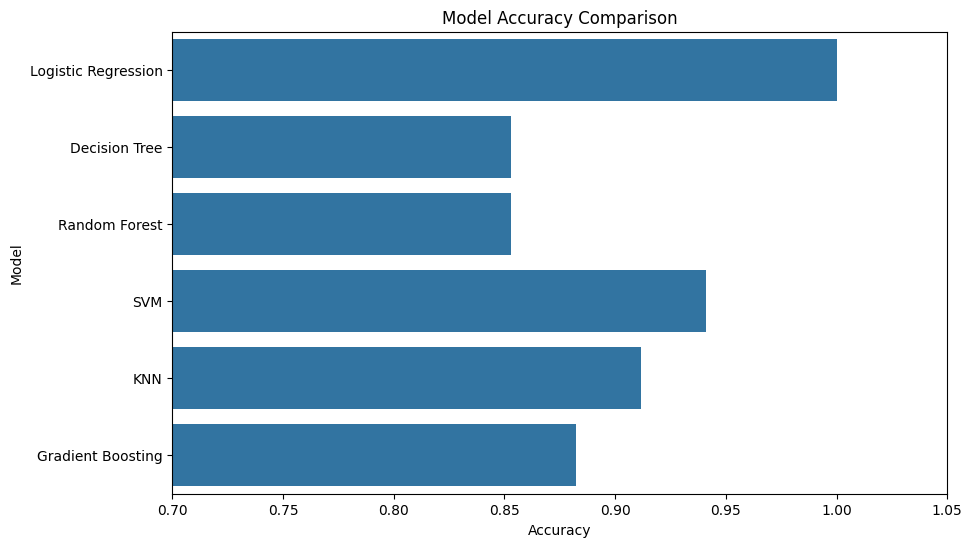

In [133]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x='Accuracy',
    y='Model'
)

plt.title('Model Accuracy Comparison')

plt.xlim(0.7, 1.05)

plt.show()

In [134]:
from xgboost import XGBClassifier

In [135]:
# XGBoost

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train_encoded)

xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(
    y_test_encoded,
    xgb_pred
)

model_results['XGBoost'] = xgb_accuracy

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.8823529411764706


In [136]:
results_df = pd.DataFrame({
    'Model': model_results.keys(),
    'Accuracy': model_results.values()
})

results_df.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
0,Logistic Regression,1.000000
3,SVM,0.941176
4,KNN,0.911765
5,Gradient Boosting,0.882353
6,XGBoost,0.882353
2,Random Forest,0.852941
1,Decision Tree,0.852941


In [137]:
from sklearn.ensemble import VotingClassifier

# Soft Voting Ensemble

voting_model = VotingClassifier(
    estimators=[
        (
            'lr',
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        ),
        
        (
            'svm',
            SVC(
                probability=True,
                random_state=42
            )
        ),
        
        (
            'gb',
            GradientBoostingClassifier(
                random_state=42
            )
        )
    ],
    
    voting='soft'
)

In [138]:
# Train model

voting_model.fit(
    X_train,
    y_train_encoded
)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(max_iter=1000,
                                                 random_state=42)),
                             ('svm', SVC(probability=True, random_state=42)),
                             ('gb',
                              GradientBoostingClassifier(random_state=42))],
                 voting='soft')

In [139]:
# Predictions

voting_pred = voting_model.predict(X_test)

In [140]:
# Accuracy score

voting_accuracy = accuracy_score(
    y_test_encoded,
    voting_pred
)

print("Voting Classifier Accuracy:", voting_accuracy)

Voting Classifier Accuracy: 0.9411764705882353


In [141]:
# Store result

model_results['Voting Classifier'] = voting_accuracy

In [142]:
# Updated comparison table

results_df = pd.DataFrame({
    'Model': model_results.keys(),
    'Accuracy': model_results.values()
})

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

results_df

,Model,Accuracy
0,Logistic Regression,1.000000
3,SVM,0.941176
7,Voting Classifier,0.941176
4,KNN,0.911765
5,Gradient Boosting,0.882353
6,XGBoost,0.882353
2,Random Forest,0.852941
1,Decision Tree,0.852941


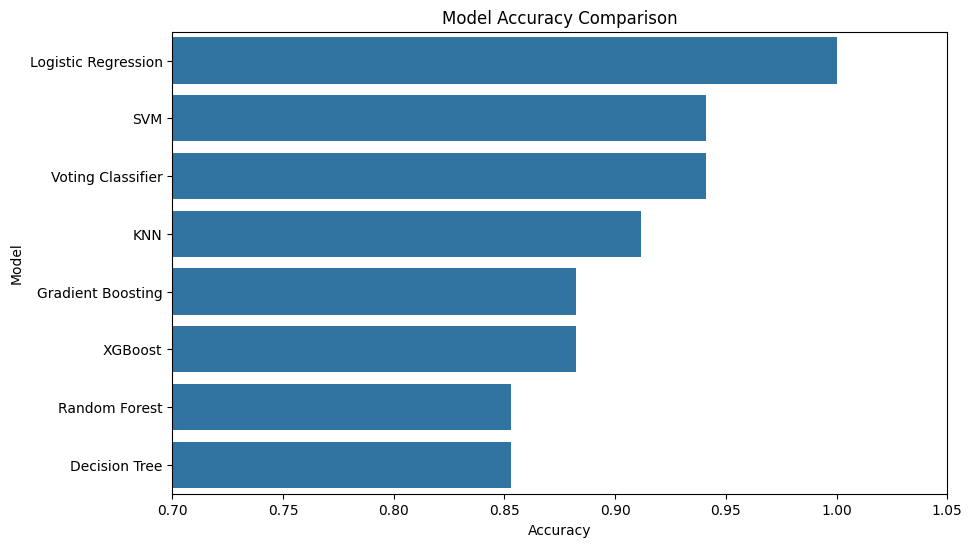

In [143]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x='Accuracy',
    y='Model'
)

plt.title('Model Accuracy Comparison')

plt.xlim(0.7, 1.05)

plt.show()

****PHASE 14: HYPERPARAMETER TUNING****

In [144]:
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold
)

In [145]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [146]:
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

In [147]:
lr_grid = GridSearchCV(
    LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    
    param_grid=lr_param_grid,
    
    cv=cv_strategy,
    
    scoring='accuracy',
    
    n_jobs=-1
)

In [148]:
lr_grid.fit(
    X_train,
    y_train_encoded
)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'solver': ['lbfgs', 'liblinear']},
             scoring='accuracy')

In [149]:
print("Best Logistic Regression Parameters:")
print(lr_grid.best_params_)

print("\nBest CV Accuracy:")
print(lr_grid.best_score_)

Best Logistic Regression Parameters:
{'C': 1, 'solver': 'lbfgs'}

Best CV Accuracy:
0.9623931623931623


In [150]:
svm_param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

In [151]:
svm_grid = GridSearchCV(
    SVC(
        probability=True,
        random_state=42
    ),
    
    param_grid=svm_param_grid,
    
    cv=cv_strategy,
    
    scoring='accuracy',
    
    n_jobs=-1
)

In [152]:
svm_grid.fit(
    X_train,
    y_train_encoded
)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=SVC(probability=True, random_state=42), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [153]:
print("Best SVM Parameters:")
print(svm_grid.best_params_)

print("\nBest CV Accuracy:")
print(svm_grid.best_score_)

Best SVM Parameters:
{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}

Best CV Accuracy:
0.9621082621082622


In [154]:
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [155]:
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    
    param_grid=knn_param_grid,
    
    cv=cv_strategy,
    
    scoring='accuracy',
    
    n_jobs=-1
)

In [156]:
knn_grid.fit(
    X_train,
    y_train_encoded
)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=KNeighborsClassifier(), n_jobs=-1,
             param_grid={'metric': ['euclidean', 'manhattan'],
                         'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']},
             scoring='accuracy')

In [157]:
print("Best KNN Parameters:")
print(knn_grid.best_params_)

print("\nBest CV Accuracy:")
print(knn_grid.best_score_)

Best KNN Parameters:
{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}

Best CV Accuracy:
0.9626780626780628


In [158]:
tuned_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'SVM',
        'KNN'
    ],
    
    'Best CV Accuracy': [
        lr_grid.best_score_,
        svm_grid.best_score_,
        knn_grid.best_score_
    ]
})

tuned_results.sort_values(
    by='Best CV Accuracy',
    ascending=False
)

,Model,Best CV Accuracy
2,KNN,0.962678
0,Logistic Regression,0.962393
1,SVM,0.962108


****PHASE 15: FINAL MODEL EVALUATION****

In [159]:
print(knn_grid.best_params_)
print(lr_grid.best_params_)
print(svm_grid.best_params_)

{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
{'C': 1, 'solver': 'lbfgs'}
{'C': 1, 'gamma': 'scale', 'kernel': 'linear'}


In [160]:
final_knn = KNeighborsClassifier(
    n_neighbors=knn_grid.best_params_['n_neighbors'],
    weights=knn_grid.best_params_['weights'],
    metric=knn_grid.best_params_['metric']
)

final_knn.fit(X_train, y_train_encoded)

knn_final_pred = final_knn.predict(X_test)

In [161]:
final_lr = LogisticRegression(
    C=lr_grid.best_params_['C'],
    solver=lr_grid.best_params_['solver'],
    max_iter=1000,
    random_state=42
)

final_lr.fit(X_train, y_train_encoded)

lr_final_pred = final_lr.predict(X_test)

In [162]:
final_svm = SVC(
    C=svm_grid.best_params_['C'],
    kernel=svm_grid.best_params_['kernel'],
    gamma=svm_grid.best_params_['gamma'],
    probability=True,
    random_state=42
)

final_svm.fit(X_train, y_train_encoded)

svm_final_pred = final_svm.predict(X_test)

In [163]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

In [164]:
def evaluate_model(model_name, y_true, y_pred):
    
    accuracy = accuracy_score(y_true, y_pred)
    
    precision = precision_score(
        y_true,
        y_pred,
        average='weighted'
    )
    
    recall = recall_score(
        y_true,
        y_pred,
        average='weighted'
    )
    
    f1 = f1_score(
        y_true,
        y_pred,
        average='weighted'
    )
    
    print(f"\n{model_name} Evaluation")
    print("-" * 40)
    
    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1 Score:", round(f1, 4))
    
    print("\nClassification Report:\n")
    
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=label_encoder.classes_
        )
    )

In [165]:
evaluate_model(
    "Tuned KNN",
    y_test_encoded,
    knn_final_pred
)

evaluate_model(
    "Tuned Logistic Regression",
    y_test_encoded,
    lr_final_pred
)

evaluate_model(
    "Tuned SVM",
    y_test_encoded,
    svm_final_pred
)


Tuned KNN Evaluation
----------------------------------------
Accuracy: 0.8824
Precision: 0.8907
Recall: 0.8824
F1 Score: 0.8834

Classification Report:

                precision    recall  f1-score   support

     Developed       0.91      0.83      0.87        12
    Developing       0.81      0.93      0.87        14
Underdeveloped       1.00      0.88      0.93         8

      accuracy                           0.88        34
     macro avg       0.91      0.88      0.89        34
  weighted avg       0.89      0.88      0.88        34


Tuned Logistic Regression Evaluation
----------------------------------------
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Classification Report:

                precision    recall  f1-score   support

     Developed       1.00      1.00      1.00        12
    Developing       1.00      1.00      1.00        14
Underdeveloped       1.00      1.00      1.00         8

      accuracy                           1.00        34
     macr

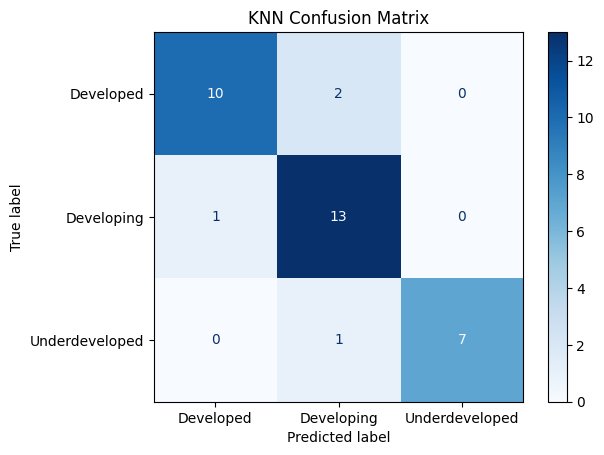

In [166]:
cm_knn = confusion_matrix(
    y_test_encoded,
    knn_final_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=label_encoder.classes_
)

disp.plot(cmap='Blues')

plt.title("KNN Confusion Matrix")

plt.show()

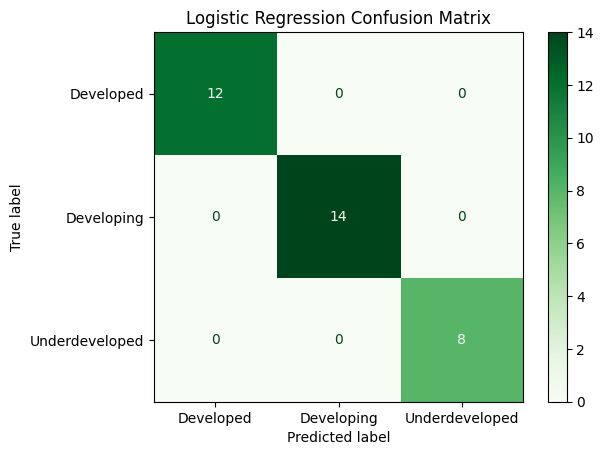

In [167]:
cm_lr = confusion_matrix(
    y_test_encoded,
    lr_final_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=label_encoder.classes_
)

disp.plot(cmap='Greens')

plt.title("Logistic Regression Confusion Matrix")

plt.show()

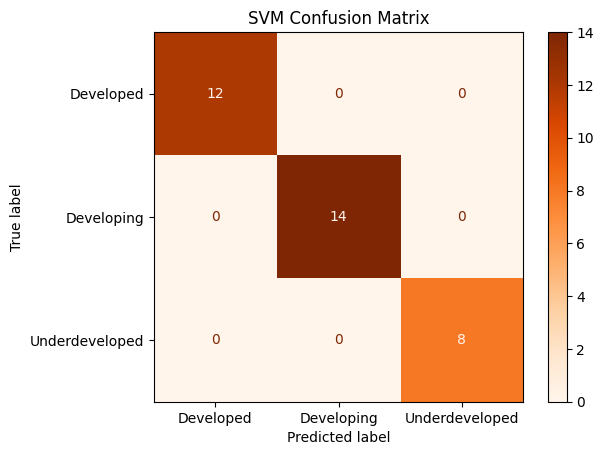

In [168]:
cm_svm = confusion_matrix(
    y_test_encoded,
    svm_final_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap='Oranges')

plt.title("SVM Confusion Matrix")

plt.show()

In [169]:
# Tuned Voting Ensemble

final_voting_model = VotingClassifier(
    estimators=[
        (
            'lr',
            final_lr
        ),
        
        (
            'svm',
            final_svm
        ),
        
        (
            'knn',
            final_knn
        )
    ],
    
    voting='soft'
)

In [170]:
# Train tuned ensemble

final_voting_model.fit(
    X_train,
    y_train_encoded
)

VotingClassifier(estimators=[('lr',
                              LogisticRegression(C=1, max_iter=1000,
                                                 random_state=42)),
                             ('svm',
                              SVC(C=1, kernel='linear', probability=True,
                                  random_state=42)),
                             ('knn',
                              KNeighborsClassifier(metric='euclidean',
                                                   n_neighbors=7))],
                 voting='soft')

In [171]:
# Predictions

voting_final_pred = final_voting_model.predict(X_test)

In [172]:
evaluate_model(
    "Tuned Voting Ensemble",
    y_test_encoded,
    voting_final_pred
)


Tuned Voting Ensemble Evaluation
----------------------------------------
Accuracy: 0.9706
Precision: 0.9725
Recall: 0.9706
F1 Score: 0.9705

Classification Report:

                precision    recall  f1-score   support

     Developed       1.00      0.92      0.96        12
    Developing       0.93      1.00      0.97        14
Underdeveloped       1.00      1.00      1.00         8

      accuracy                           0.97        34
     macro avg       0.98      0.97      0.97        34
  weighted avg       0.97      0.97      0.97        34



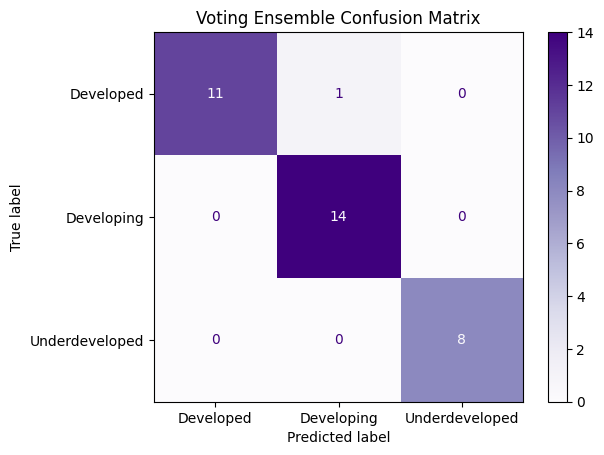

In [173]:
cm_voting = confusion_matrix(
    y_test_encoded,
    voting_final_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_voting,
    display_labels=label_encoder.classes_
)

disp.plot(cmap='Purples')

plt.title("Voting Ensemble Confusion Matrix")

plt.show()

In [174]:
final_results = pd.DataFrame({
    'Model': [
        'Tuned Logistic Regression',
        'Tuned SVM',
        'Tuned KNN',
        'Tuned Voting Ensemble'
    ],
    
    'Accuracy': [
        accuracy_score(y_test_encoded, lr_final_pred),
        accuracy_score(y_test_encoded, svm_final_pred),
        accuracy_score(y_test_encoded, knn_final_pred),
        accuracy_score(y_test_encoded, voting_final_pred)
    ]
})

final_results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
0,Tuned Logistic Regression,1.000000
1,Tuned SVM,1.000000
3,Tuned Voting Ensemble,0.970588
2,Tuned KNN,0.882353


****PHASE 16: SAVING OBJECTS****

In [175]:
from sklearn.pipeline import Pipeline
import joblib

In [176]:
lr_pipeline = Pipeline([
    ('scaler', scaler),
    ('pca', pca),
    ('classifier', final_lr)
])

In [177]:
svm_pipeline = Pipeline([
    ('scaler', scaler),
    ('pca', pca),
    ('classifier', final_svm)
])

In [178]:
knn_pipeline = Pipeline([
    ('scaler', scaler),
    ('pca', pca),
    ('classifier', final_knn)
])

In [179]:
voting_pipeline = Pipeline([
    ('scaler', scaler),
    ('pca', pca),
    ('classifier', final_voting_model)
])

In [180]:
joblib.dump(scaler, 'scaler.pkl')

joblib.dump(pca, 'pca.pkl')

joblib.dump(final_lr, 'logistic_regression_model.pkl')

joblib.dump(final_svm, 'svm_model.pkl')

joblib.dump(final_knn, 'knn_model.pkl')

joblib.dump(final_voting_model, 'voting_ensemble_model.pkl')

['voting_ensemble_model.pkl']

In [181]:
joblib.dump(
    lr_pipeline,
    'logistic_regression_pipeline.pkl'
)

joblib.dump(
    svm_pipeline,
    'svm_pipeline.pkl'
)

joblib.dump(
    knn_pipeline,
    'knn_pipeline.pkl'
)

joblib.dump(
    voting_pipeline,
    'voting_pipeline.pkl'
)

['voting_pipeline.pkl']

In [182]:
import os

saved_files = [
    'scaler.pkl',
    'pca.pkl',
    'logistic_regression_model.pkl',
    'svm_model.pkl',
    'knn_model.pkl',
    'voting_ensemble_model.pkl',
    'logistic_regression_pipeline.pkl',
    'svm_pipeline.pkl',
    'knn_pipeline.pkl',
    'voting_pipeline.pkl'
]

for file in saved_files:
    
    print(
        file,
        "->",
        os.path.exists(file)
    )

scaler.pkl -> True
pca.pkl -> True
logistic_regression_model.pkl -> True
svm_model.pkl -> True
knn_model.pkl -> True
voting_ensemble_model.pkl -> True
logistic_regression_pipeline.pkl -> True
svm_pipeline.pkl -> True
knn_pipeline.pkl -> True
voting_pipeline.pkl -> True


In [183]:
# Decode predictions

actual_labels = label_encoder.inverse_transform(
    y_test_encoded
)

predicted_labels = label_encoder.inverse_transform(
    voting_final_pred
)

In [184]:
ensemble_results_df = pd.DataFrame({
    'Actual_Label': actual_labels,
    'Predicted_Label': predicted_labels
})

In [185]:
ensemble_results_df['Correct_Prediction'] = (
    ensemble_results_df['Actual_Label']
    ==
    ensemble_results_df['Predicted_Label']
)

In [186]:
ensemble_results_df.head()

,Actual_Label,Predicted_Label,Correct_Prediction
0,Developing,Developing,True
1,Developed,Developed,True
2,Developing,Developing,True
3,Developed,Developed,True
4,Developing,Developing,True


In [187]:
ensemble_results_df.to_csv(
    'ensemble_model_predictions.csv',
    index=False
)

print("CSV saved successfully.")

CSV saved successfully.


In [188]:
final_country_clusters = df[["country"]].copy()

final_country_clusters['Cluster'] = (
    kmeans_result_df['KMeans_Cluster']
)

final_country_clusters['Country_Label'] = (
    kmeans_result_df['Country_Label']
)

print(final_country_clusters.shape)
final_country_clusters.head()

(167, 3)


,country,Cluster,Country_Label
0,Afghanistan,2,Underdeveloped
1,Albania,1,Developed
2,Algeria,0,Developing
3,Angola,0,Developing
4,Antigua and Barbuda,1,Developed


In [189]:
final_country_clusters.to_csv(
    'final_country_clusters.csv',
    index=False
)

print("Clustered country dataset exported.")

Clustered country dataset exported.
